# 04 — Credit Portfolio: Gaussian Copula, Quadrature, and Large Losses

## Module 4-core: systemic credit risk

This notebook studies a homogeneous credit portfolio with dependent defaults
under the one-factor Gaussian copula model.

The objective is now more precise than a visual lab:

```text
copula model
→ conditional binomial loss
→ quadrature benchmark over the factor Z
→ numerical validation of Pham's Theorem 6.1
```

We move from independent Bernoulli defaults,

$$
L_n=Y_1+\cdots+Y_n,
\qquad
Y_k\sim \mathrm{Bernoulli}(p),
$$

to a one-factor Gaussian copula model where all obligors share a common factor $Z$:

$$
X_k=\rho Z+\sqrt{1-\rho^2}\,\varepsilon_k.
$$

The key computational identity is:

$$
L_n\mid Z=z
\sim
\mathrm{Binomial}(n,p(z)).
$$

This identity lets us compute portfolio tail probabilities by one-dimensional
quadrature instead of relying on naive Monte Carlo.

| Parameter | Interpretation |
|---|---|
| $p$ | Marginal default probability |
| $\rho$ | Systematic factor loading |
| $z$ | Macro/systematic scenario |
| $q$ | Loss threshold |
| $q_n$ | Extreme threshold approaching 1 |
| $n$ | Portfolio size |
| $a$ | Speed at which $q_n$ goes to 1 |


## Position in the project

We have so far built the independent rare-event machinery:

| Step | Notebook | Main idea |
|---:|---|---|
| 1 | Notebook 01 | Exponential tilting for Bernoulli variables |
| 2 | Notebook 02 | Cramer's theorem for independent Bernoulli tail risk |
| 3 | Notebook 03 | Importance sampling for independent Bernoulli rare events |

Notebook 04 changes the regime.

Here we introduce dependent defaults through the one-factor Gaussian copula, then
use the conditional structure to compute large-loss probabilities.

The central formula is:

$$
p(Z)
=
\Phi\left(
\frac{\rho Z+\Phi^{-1}(p)}
{\sqrt{1-\rho^2}}
\right).
$$

The theorem we want to check numerically is Pham's large-loss asymptotic:

$$
\frac{1}{\log n}
\log \mathbb P(L_n\geq n q_n)
\longrightarrow
-a\frac{1-\rho^2}{\rho^2},
$$

where

$$
q_n = 1-c n^{-a}.
$$

This notebook is therefore the first full module-4 benchmark:

```text
not Monte Carlo first;
quadrature first;
importance sampling later.
```


## 1. Imports and Project Setup

The notebook can be run from the repository root, from the `notebooks/`
directory, or from an installed environment.

When the project package is available, it uses `large_deviations.credit`.
To keep the lab portable, the notebook also includes small fallback formulas;
this makes the `.ipynb` readable even outside the full repository.

Interactive figures are built with **Plotly**:

```bash
pip install plotly


In [1]:
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm
from IPython.display import display, Markdown

try:
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError(
        "This interactive lab needs Plotly. Install it with: pip install plotly"
    ) from exc

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from large_deviations.credit import (
    asset_threshold,
    conditional_default_probability,
    gaussian_copula_large_loss_decay_rate,
    large_loss_threshold_qn,
    sample_gaussian_copula_losses,
)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": True,
    }
)

BASE_SEED = 20260507

print("Formula source: large_deviations.credit")

# Sharper static outputs in notebooks / GitHub previews.
try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except NameError:
    pass


Formula source: large_deviations.credit


## 1.1 Lab utilities

Two small helpers keep the notebook focused on the credit-risk mechanics:

- `limiting_dependent_tail_probability`: exact large-portfolio fixed-threshold limit, $P[p(Z) \ge q]$.
- `export_interactive_figure`: optionally writes Plotly figures to `docs/interactive/` as standalone HTML (disabled by default).


In [ ]:
# Optional export of Plotly figures to docs/interactive/ (disabled by default).
EXPORT_INTERACTIVE_HTML = False


def interactive_output_dir() -> Path:
    """Return docs/interactive whether the notebook runs from the root or notebooks/."""
    cwd = Path.cwd().resolve()
    root = cwd.parent if cwd.name == "notebooks" else cwd
    return root / "docs" / "interactive"


def export_interactive_figure(fig: go.Figure, filename: str) -> None:
    """Write an interactive Plotly figure to docs/interactive/ when exports are enabled."""
    if not EXPORT_INTERACTIVE_HTML:
        return

    out_dir = interactive_output_dir()
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    fig.write_html(out_path)
    print(f"Exported: {out_path}")


def limiting_dependent_tail_probability(q: float, p: float, rho: float) -> float:
    """Large-n fixed-threshold limit: P[L_n/n >= q] -> P[p(Z) >= q] for rho > 0."""
    if q <= 0.0:
        return 1.0
    if q >= 1.0:
        return 0.0

    if abs(rho) < 1e-14:
        return float(q <= p)

    z_star = (math.sqrt(1.0 - rho**2) * norm.ppf(q) - norm.ppf(p)) / rho
    return float(norm.sf(z_star))


## 1.2 Quadrature and asymptotic helpers

The quadrature and large-loss asymptotic routines now live in the package module, so the notebook imports them directly from `large_deviations.credit`.


In [4]:
from large_deviations.credit import (
    CreditTailQuadratureResult,
    LargeLossAsymptoticPoint,
    LargeLossAsymptoticResult,
    asymptotic_points_to_records,
    conditional_binomial_tail_probability,
    credit_tail_integrand,
    credit_tail_probability_quadrature,
    estimate_loglog_decay_rate,
    factor_threshold_for_conditional_default_probability,
    log_conditional_binomial_tail_probability,
    log_credit_tail_integrand,
    loss_count_threshold,
    compute_large_loss_asymptotic_curve,
    compute_large_loss_asymptotic_point,
)

print("Quadrature source: large_deviations.credit")


Quadrature source: large_deviations.credit


## 2. What is a copula?

A marginal default probability describes the risk of a single obligor:

$$
\mathbb P(Y_k = 1) = p.
$$

A credit portfolio, however, is driven by the joint behavior of many obligors:

$$
(Y_1,\ldots,Y_n).
$$

Two portfolios can share the same marginal default probability $p$ while having very different default clustering:

- **Portfolio A:** defaults are nearly independent.
- **Portfolio B:** defaults are driven by a common macro factor.

A copula separates these two ingredients:

- the marginal behavior of each obligor;
- the dependence structure linking obligors together.

The Gaussian copula does this by using correlated normal variables to create dependent uniform variables, which are then converted into default indicators.

For a beginner-friendly explanation, see [`docs/credit/copulas_from_scratch.md`](../docs/credit/copulas_from_scratch.md).

## 3. One-factor Gaussian copula model

For each obligor $k$, define a latent credit variable

$$
X_k
=
\rho Z + \sqrt{1-\rho^2}\,\varepsilon_k,
$$

where:

- $Z \sim N(0,1)$ is the systematic factor;
- $\varepsilon_k \sim N(0,1)$ is the idiosyncratic noise;
- $Z,\varepsilon_1,\ldots,\varepsilon_n$ are mutually independent;
- $0 \le \rho < 1$.

Because $X_k$ is a linear combination of independent standard normal variables with total variance one, each $X_k$ is also standard normal.

Default occurs when the latent variable crosses the default threshold:

$$
X_k > x_p,
\qquad
x_p = \Phi^{-1}(1-p).
$$

This threshold is chosen so that the marginal default probability is exactly

$$
\mathbb P(Y_k = 1) = p.
$$

In the homogeneous one-factor model, dependence comes entirely from the shared factor $Z$:

$$
\operatorname{Corr}(X_i, X_j) = \rho^2,
\qquad i \ne j.
$$

Thus, $\rho$ is the systematic factor loading, while $\rho^2$ is the pairwise latent correlation between obligors.


## 4. Conditional default probability

Condition on $Z=z$.

Then:

$$
X_k=\rho z+\sqrt{1-\rho^2}\varepsilon_k.
$$

So:

$$
p(z)
=
\mathbb P(Y_k=1\mid Z=z)
=
\Phi\left(
\frac{\rho z+\Phi^{-1}(p)}
{\sqrt{1-\rho^2}}
\right).
$$

Given $Z=z$, defaults are independent Bernoulli variables with probability $p(z)$.

Therefore:

$$
L_n\mid Z=z
\sim
\mathrm{Binomial}(n,p(z)).
$$

This is the whole computational trick of the one-factor model.

## 5. Parameters

We use the same baseline marginal default probability as the previous notebooks:

$$
p=2\%.
$$

The correlation parameter $\rho$ will vary.

In [2]:
from IPython.display import Markdown, display
from scipy.stats import norm

p = 0.02
rho_values = [0.0, 0.2, 0.5, 0.8]
x_p = norm.ppf(1 - p)

display(Markdown(f"""
| quantity | value |
|---|---:|
| marginal default probability $p$ | ${p:.6f}$ |
| default threshold $x_p = \\Phi^{{-1}}(1-p)$ | ${x_p:.6f}$ |
| lower-tail quantile $\\Phi^{{-1}}(p)$ | ${norm.ppf(p):.6f}$ |
"""))



| quantity | value |
|---|---:|
| marginal default probability $p$ | $0.020000$ |
| default threshold $x_p = \Phi^{-1}(1-p)$ | $2.053749$ |
| lower-tail quantile $\Phi^{-1}(p)$ | $-2.053749$ |


The threshold $x_p$ is high because default is rare.

For $p=2\%$, default happens when a standard normal latent variable lands above the 98th percentile.

## 6. Systemic stress curve: how $p(z)$ reacts to $Z$

The function $p(z)$ is the default probability conditional on the systematic factor taking the value $Z=z$.

With the convention used here, larger values of $z$ represent worse systematic states, because default occurs when

$$
X_k > x_p.
$$

The slider below shows how the factor loading $\rho$ changes the sensitivity of conditional default risk:

- when $\rho$ is low, $p(z)$ is almost flat;
- when $\rho$ is high, $p(z)$ reacts sharply to systematic stress.


### Static output: systemic stress fan chart

The interactive slider is useful when running the notebook locally. This static figure provides the GitHub-friendly view of the same mechanism.

It highlights the central effect of dependence:

$$
\text{same marginal } p
\quad + \quad
\text{larger } \rho
\quad \Longrightarrow \quad
p(z) \text{ becomes much more sensitive to } Z.
$$


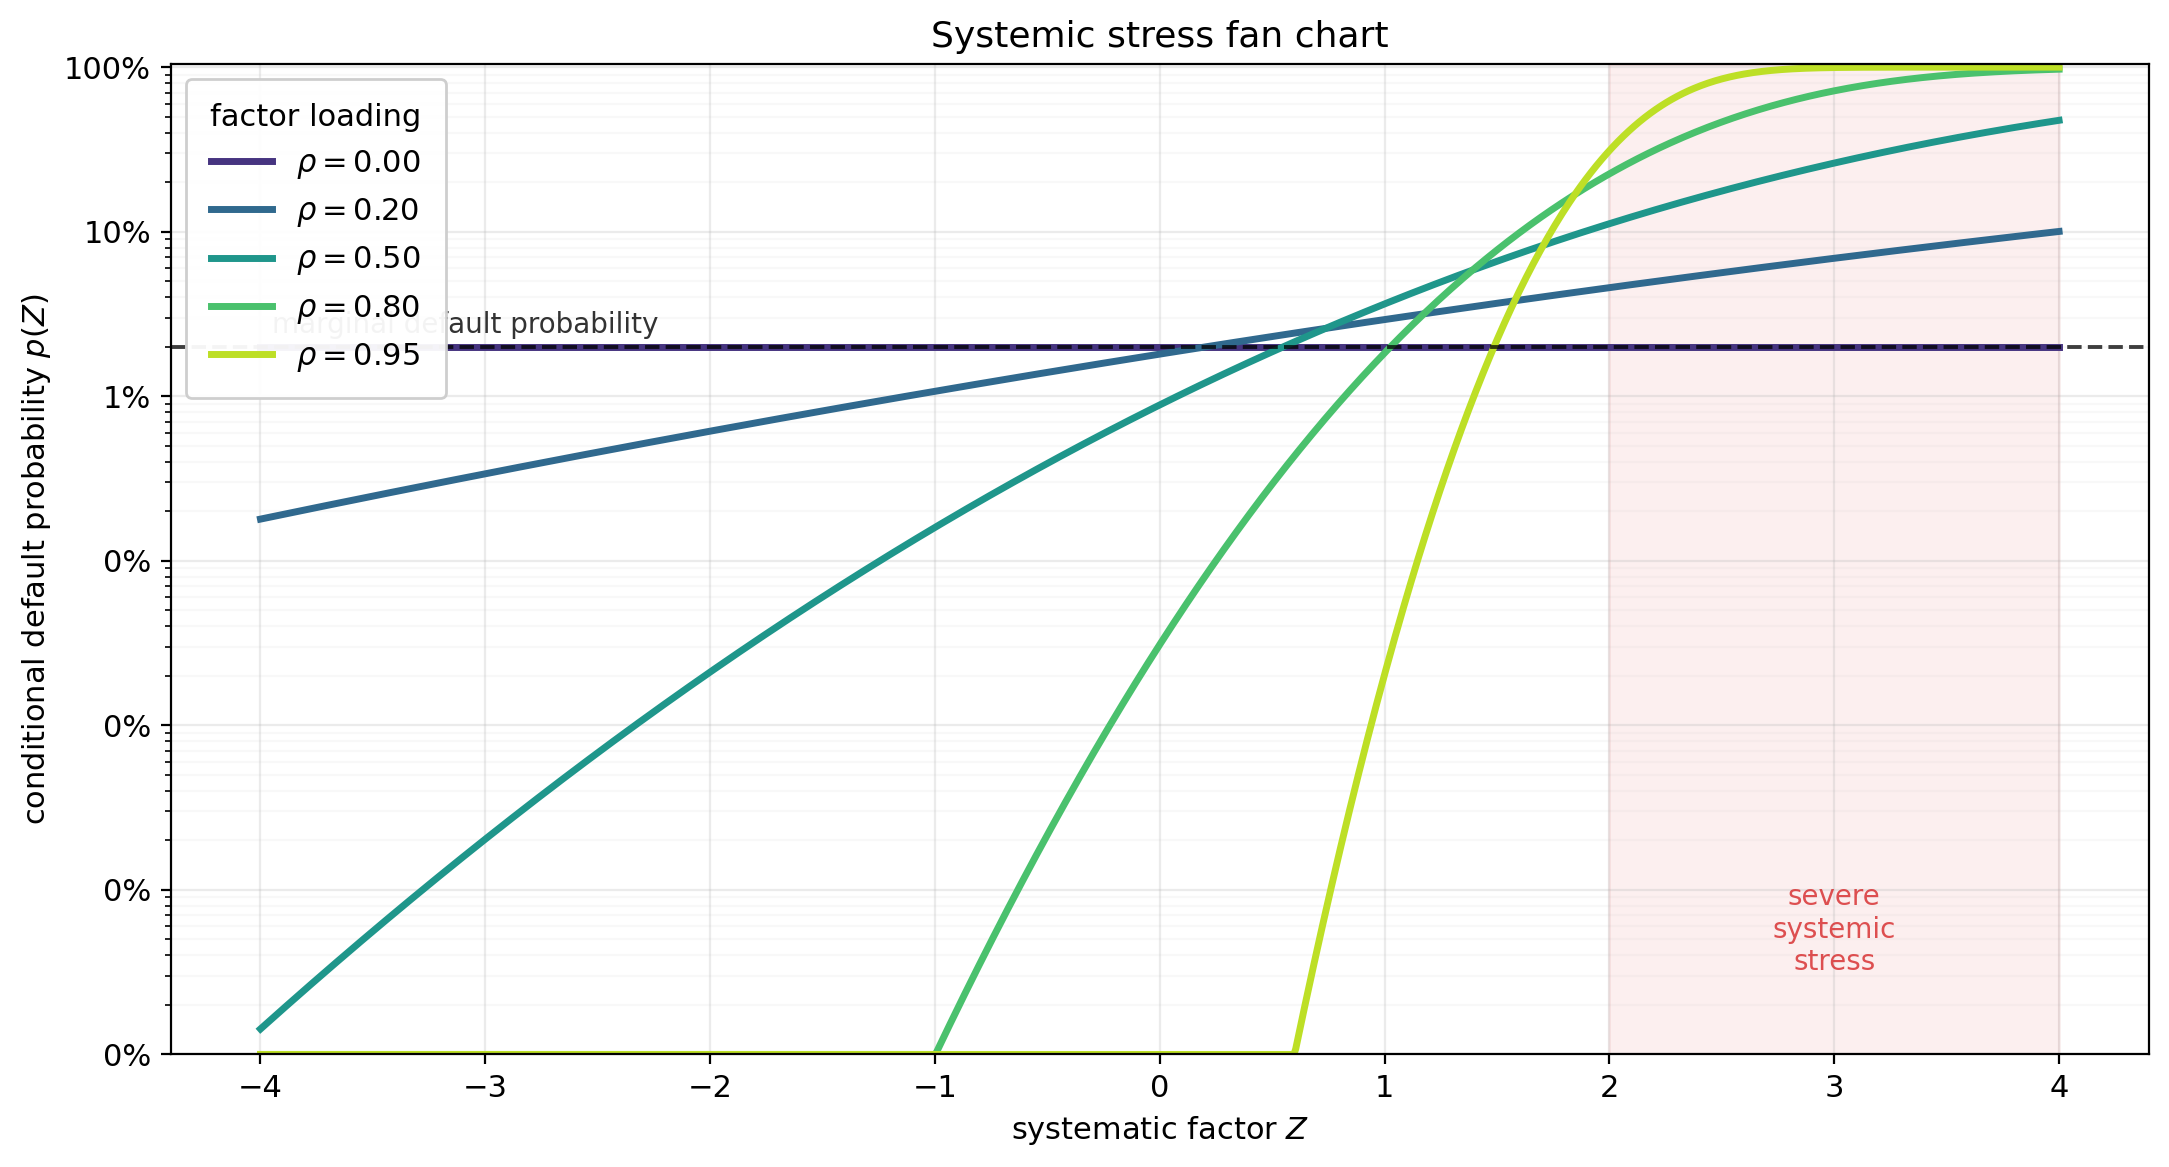

In [9]:
from matplotlib.ticker import PercentFormatter
import matplotlib.lines as mlines

z_grid_static = np.linspace(-4.0, 4.0, 1_000)
rho_static_values = [0.0, 0.2, 0.5, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(11, 6))

colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(rho_static_values)))

for rho, color in zip(rho_static_values, colors):
    p_z_curve = conditional_default_probability(z_grid_static, p=p, rho=rho)
    ax.plot(
        z_grid_static,
        np.clip(p_z_curve, 1e-6, 1.0),
        linewidth=2.5,
        color=color,
        label=fr"$\rho = {rho:.2f}$",
    )

ax.axhline(p, color="black", linestyle="--", linewidth=1.4, alpha=0.75)
ax.axvspan(2.0, 4.0, color="tab:red", alpha=0.07)

ax.text(
    -3.95,
    p * 1.12,
    "marginal default probability",
    color="black",
    fontsize=10,
    va="bottom",
    alpha=0.8,
)

ax.text(
    3.0,
    3e-6,
    "severe\nsystemic\nstress",
    color="tab:red",
    fontsize=10,
    ha="center",
    va="bottom",
    alpha=0.8,
)

ax.set_yscale("log")
ax.set_ylim(1e-6, 1.05)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("systematic factor $Z$")
ax.set_ylabel("conditional default probability $p(Z)$")
ax.set_title("Systemic stress fan chart")

ax.legend(
    title="factor loading",
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    borderpad=0.8,
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.08)

plt.tight_layout()
plt.show()


In [10]:
z_points = np.array([-3.0, -2.0, 0.0, 2.0, 3.0])

rows = []

for rho in rho_values:
    conditional_ps = conditional_default_probability(z_points, p=p, rho=rho)

    row = {"rho": rho}
    for z, p_z in zip(z_points, conditional_ps):
        row[f"p(z={z:g})"] = p_z
    rows.append(row)

conditional_table = pd.DataFrame(rows)
display(conditional_table.style.format(precision=6))

,rho,p(z=-3),p(z=-2),p(z=0),p(z=2),p(z=3)
0,0.000000,0.020000,0.020000,0.020000,0.020000,0.020000
1,0.200000,0.003380,0.006134,0.018037,0.045720,0.068941
2,0.500000,0.000020,0.000211,0.008859,0.111847,0.261277
3,0.800000,0.000000,0.000000,0.000310,0.224750,0.718059


In [12]:
z_grid = np.linspace(-4.0, 4.0, 700)
rho_slider_values = np.round(np.linspace(0.0, 0.95, 20), 2)

fig = go.Figure()

for i, rho in enumerate(rho_slider_values):
    p_z = conditional_default_probability(z_grid, p=p, rho=float(rho))

    fig.add_trace(
        go.Scatter(
            x=z_grid,
            y=p_z,
            mode="lines",
            name=fr"rho={rho:.2f}",
            visible=(i == 0),
            hovertemplate="z=%{x:.2f}<br>p(z)=%{y:.3%}<extra></extra>",
        )
    )

# Marginal p reference line, always visible.
fig.add_trace(
    go.Scatter(
        x=z_grid,
        y=np.full_like(z_grid, p),
        mode="lines",
        name="marginal p",
        line=dict(dash="dash"),
        visible=True,
        hovertemplate="marginal p=%{y:.3%}<extra></extra>",
    )
)

steps = []
for i, rho in enumerate(rho_slider_values):
    visible = [False] * len(rho_slider_values) + [True]
    visible[i] = True

    stress_p = conditional_default_probability(3.0, p=p, rho=float(rho))
    title = (
        "Systemic stress curve: "
        f"rho={rho:.2f}, p(Z=3)={stress_p:.2%}"
    )

    steps.append(
        dict(
            method="update",
            args=[
                {"visible": visible},
                {"title": title},
            ],
            label=f"{rho:.2f}",
        )
    )

fig.update_layout(
    title="Systemic stress curve: conditional default probability p(z)",
    xaxis_title="systematic factor z",
    yaxis_title="conditional default probability p(z)",
    yaxis_tickformat=".1%",
    hovermode="x unified",
    height=600,
    sliders=[dict(active=0, currentvalue={"prefix": "rho = "}, steps=steps)],
)

fig.show()
# export_interactive_figure(fig, "01_conditional_default_probability_slider.html")

### Sensitivity to the correlation parameter

Re-run the cell above with $\rho = 0$, $\rho = 0.5$ and $\rho = 0.9$, and compare $p(Z=3)$ across the three cases. This single number answers the practical risk question: if the macro factor is very bad, how much does the portfolio default probability jump?


### Static output — stress amplification

This chart is deliberately simple: it asks how many times larger the conditional default probability becomes under a stressed macro factor.

For example, \(p(Z=3)/p = 20\) means:

```text
a 2% marginal default probability behaves like 40% conditional default probability
under that systemic scenario.
```


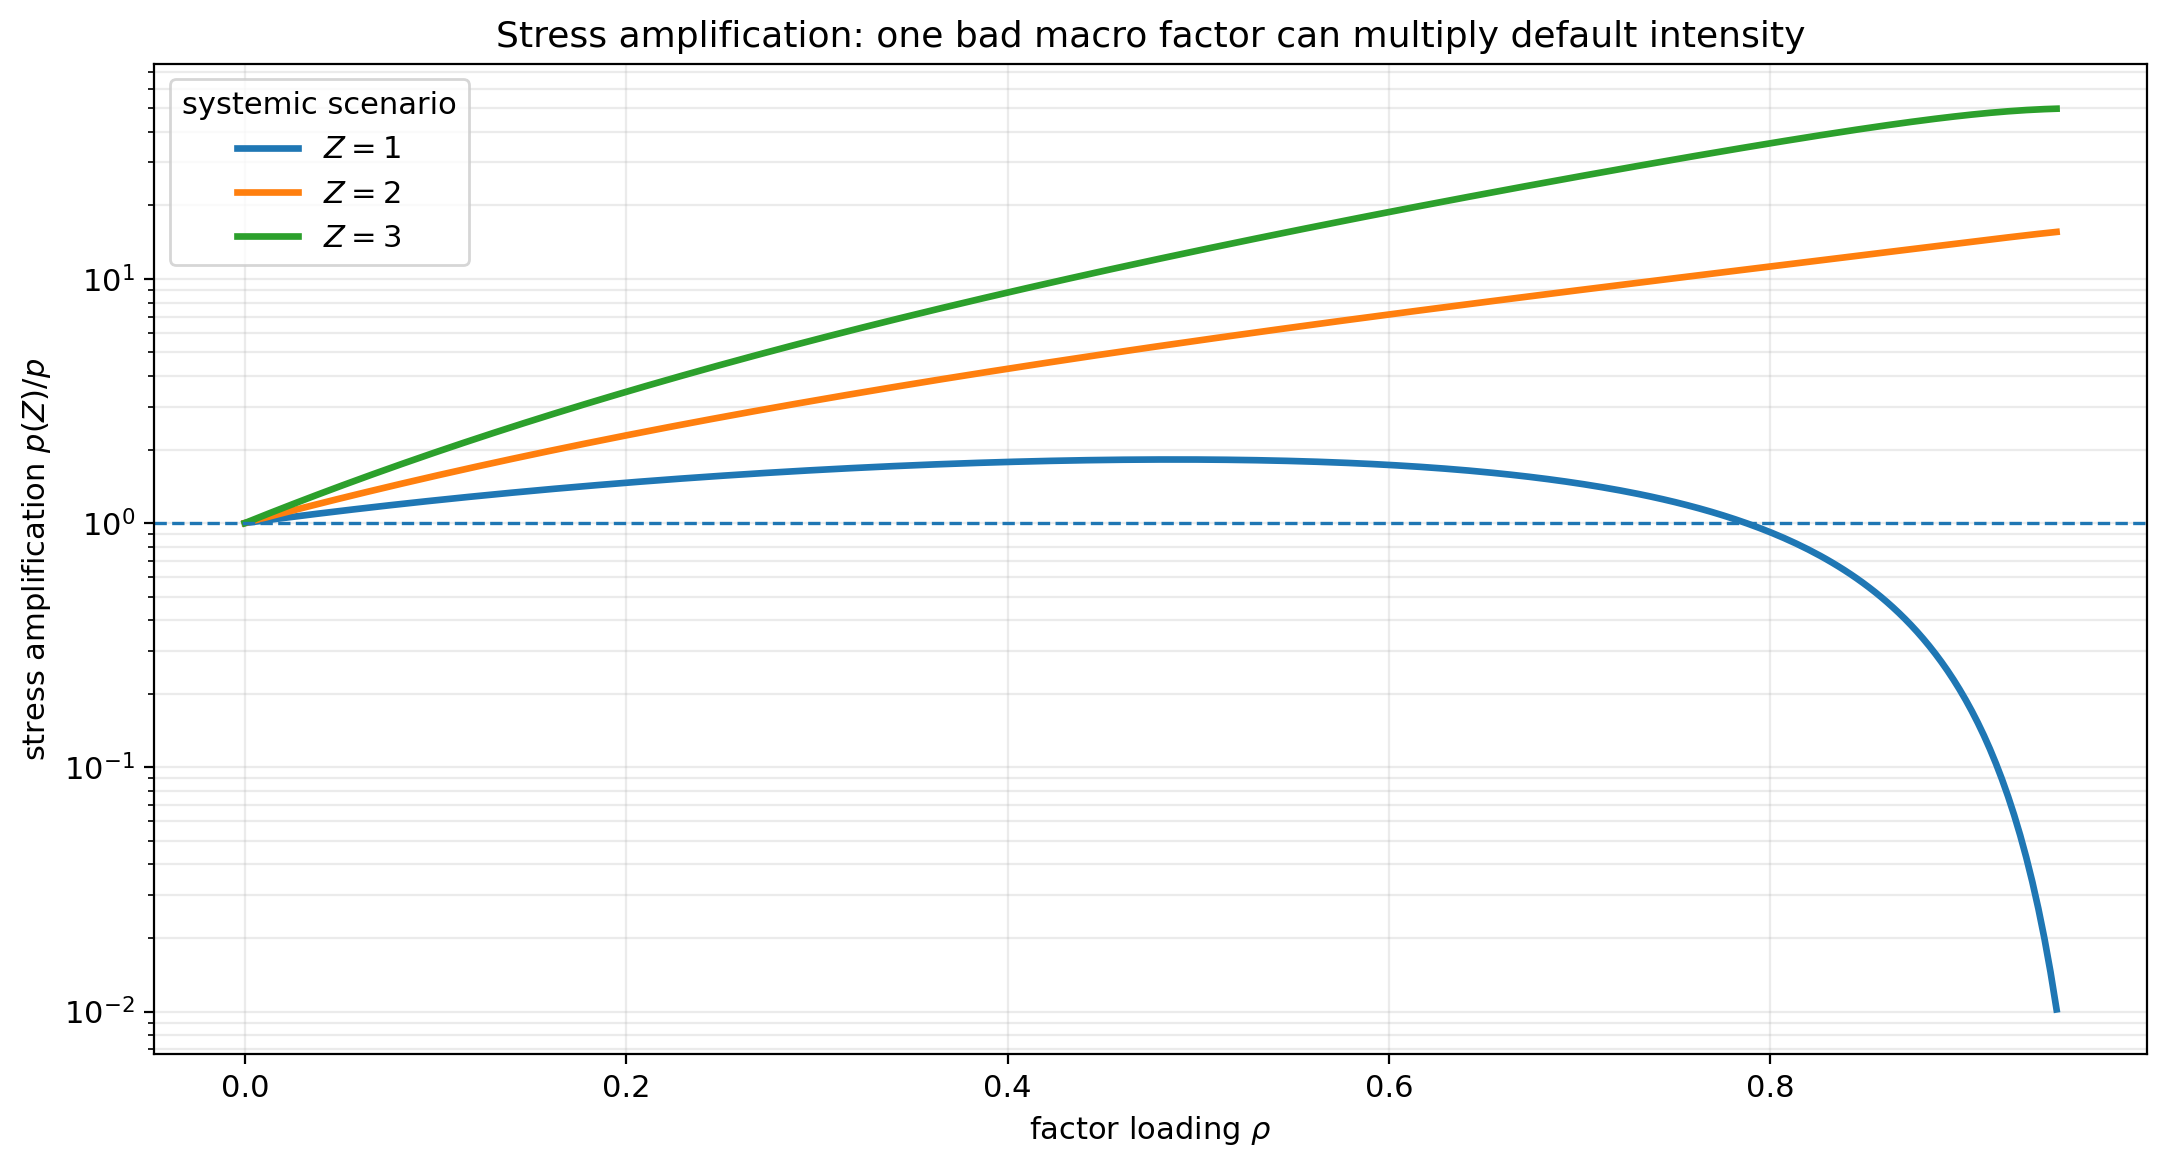

In [8]:
rho_grid_amplification = np.linspace(0.0, 0.95, 300)
stress_levels = [1.0, 2.0, 3.0]

fig, ax = plt.subplots(figsize=(11, 6))

for z_stress in stress_levels:
    amplification = np.array(
        [
            conditional_default_probability(z_stress, p=p, rho=float(rho)) / p
            for rho in rho_grid_amplification
        ]
    )
    ax.plot(
        rho_grid_amplification,
        amplification,
        linewidth=2.4,
        label=fr"$Z={z_stress:.0f}$",
    )

ax.axhline(1.0, linestyle="--", linewidth=1.2)
ax.set_yscale("log")
ax.set_xlabel(r"factor loading $\rho$")
ax.set_ylabel(r"stress amplification $p(Z)/p$")
ax.set_title("Stress amplification: one bad macro factor can multiply default intensity")
ax.legend(title="systemic scenario")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()


In [13]:
stress_rows = []

for rho in [0.0, 0.2, 0.5, 0.8, 0.95]:
    for z in [-2.0, 0.0, 2.0, 3.0]:
        stress_rows.append(
            {
                "rho": rho,
                "z": z,
                "p(z)": conditional_default_probability(z, p=p, rho=rho),
                "multiples_of_marginal_p": conditional_default_probability(z, p=p, rho=rho) / p,
            }
        )

stress_table = pd.DataFrame(stress_rows)
display(
    stress_table.pivot(index="rho", columns="z", values="p(z)")
    .style.format("{:.3%}")
)


z,-2.000000,0.000000,2.000000,3.000000
rho,,,,
0.000000,2.000%,2.000%,2.000%,2.000%
0.200000,0.613%,1.804%,4.572%,6.894%
0.500000,0.021%,0.886%,11.185%,26.128%
0.800000,0.000%,0.031%,22.475%,71.806%
0.950000,0.000%,0.000%,31.122%,99.461%


Interpretation:

```text
rho = 0:
    p(z) is flat. The factor does nothing.

rho > 0:
    p(z) becomes sensitive to the systematic factor.

large rho:
    a bad factor realization can make default probabilities explode together.
```

## 7. Sanity check: the unconditional default probability is still $p$

Even though $p(Z)$ is random, the model must preserve the marginal default probability:

$$
\mathbb E[p(Z)] = p.
$$

We check this numerically.

In [14]:
rng = np.random.default_rng(BASE_SEED)
z_samples = rng.normal(size=200_000)

rows = []

for rho in rho_values:
    p_z_samples = conditional_default_probability(z_samples, p=p, rho=rho)
    rows.append(
        {
            "rho": rho,
            "mean_p_Z": p_z_samples.mean(),
            "target_p": p,
            "absolute_error": abs(p_z_samples.mean() - p),
        }
    )

marginal_check = pd.DataFrame(rows)
display(marginal_check.style.format(precision=6))

,rho,mean_p_Z,target_p,absolute_error
0,0.000000,0.020000,0.020000,0.000000
1,0.200000,0.019978,0.020000,0.000022
2,0.500000,0.019937,0.020000,0.000063
3,0.800000,0.019907,0.020000,0.000093


The average remains close to $p$.

The dependence changes the joint distribution, not the individual marginal probability.

## 8. Simulating portfolio losses

Because

$$
L_n\mid Z
\sim
\mathrm{Binomial}(n,p(Z)),
$$

we can simulate a homogeneous portfolio in two steps:

```text
1. sample Z
2. sample L_n from Binomial(n, p(Z))
```

This avoids simulating all obligors individually.

### Static output — tail survival curves

Histograms are intuitive, but for quant risk the survival curve is more informative:

\[
q \mapsto \mathbb P(L_n/n \geq q).
\]

This is the graph that makes the tail-risk story visible.


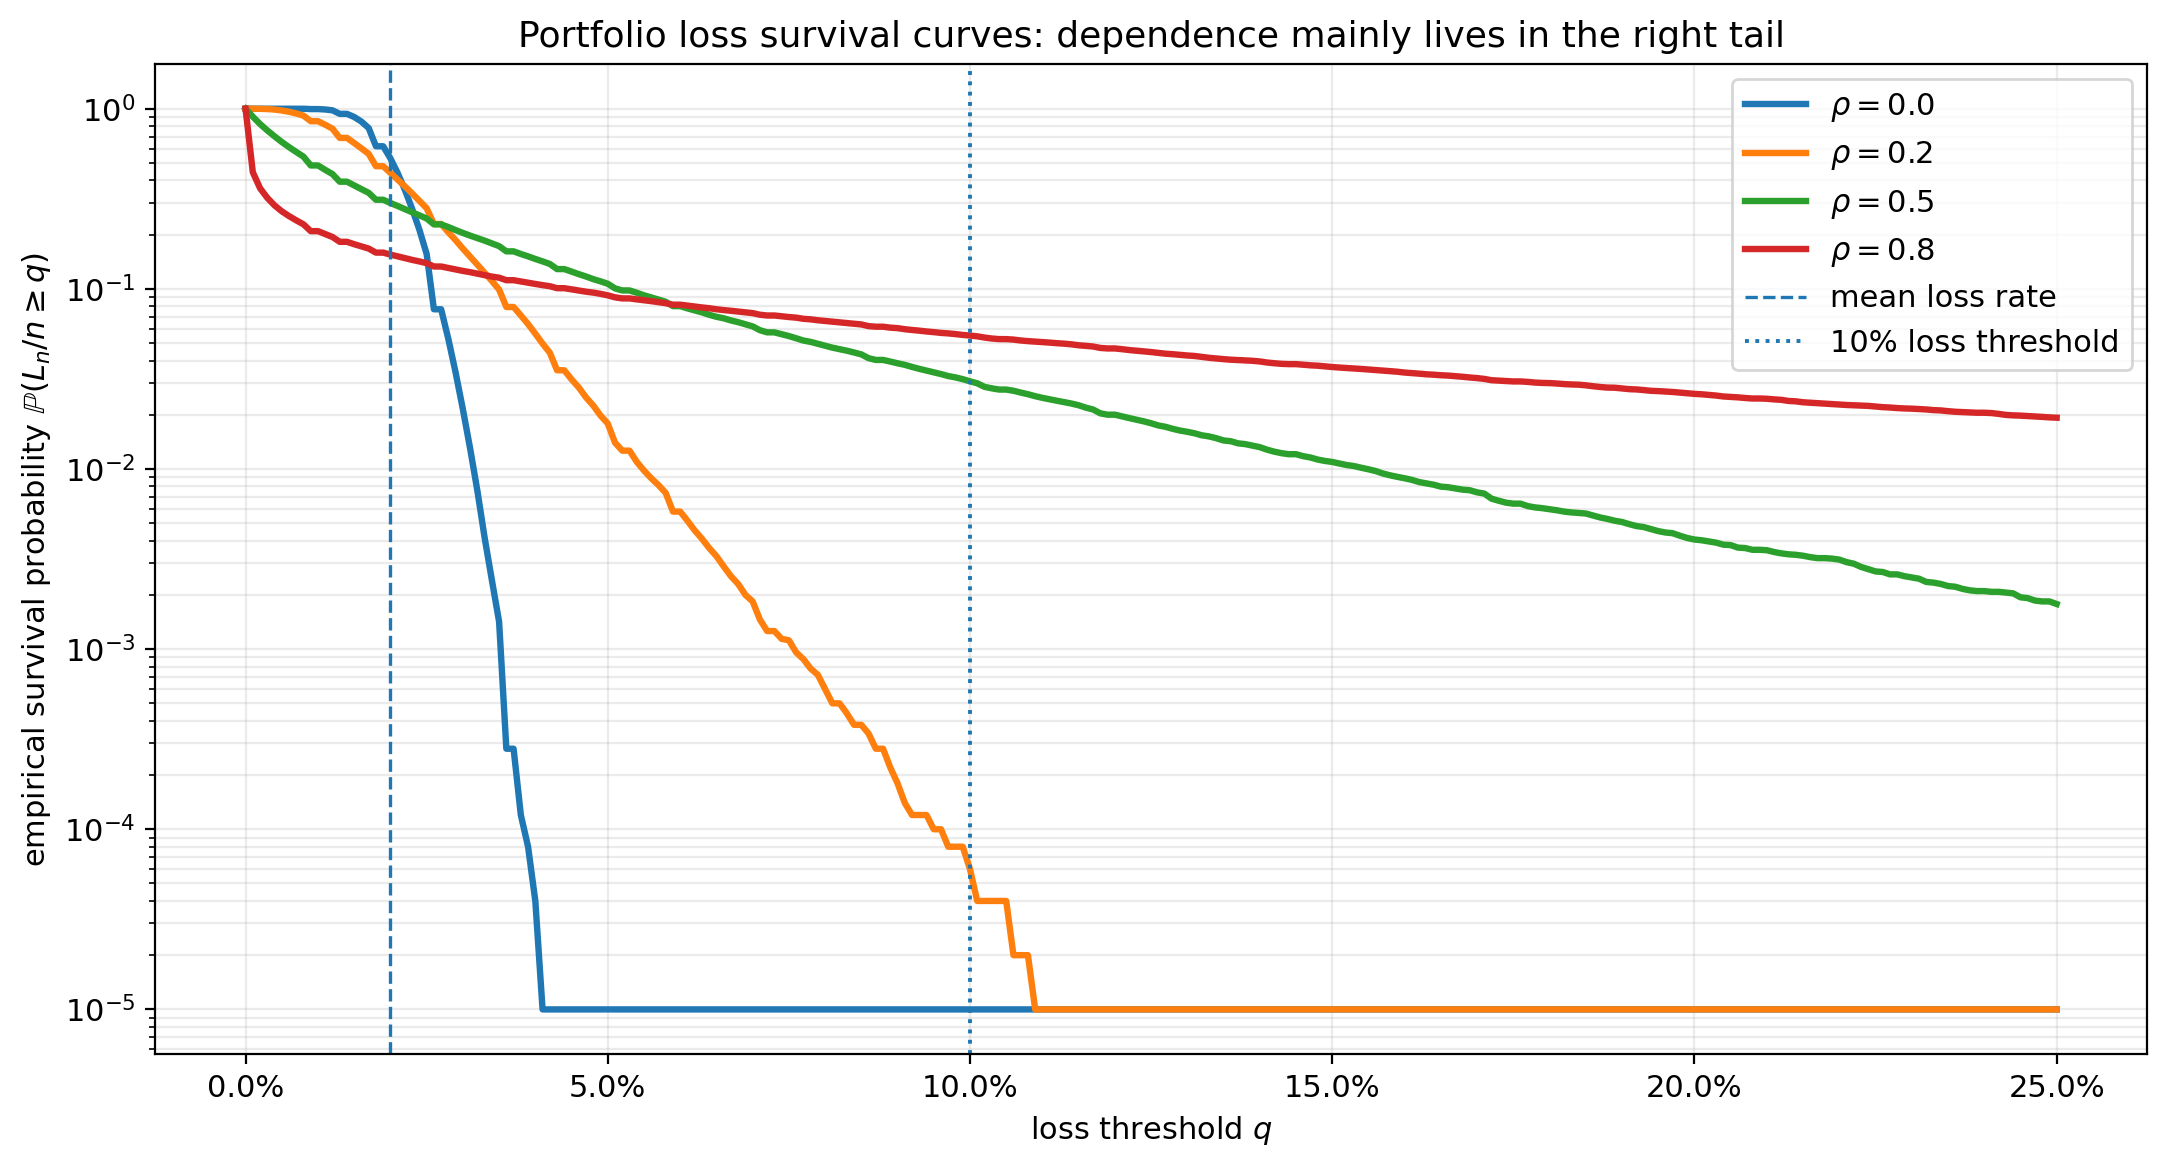

In [15]:
n_survival = 1_000
sample_size_survival = 50_000
q_grid_survival = np.linspace(0.0, 0.25, 251)
survival_floor = 0.5 / sample_size_survival
rho_survival_values = [0.0, 0.2, 0.5, 0.8]

fig, ax = plt.subplots(figsize=(11, 6))

for idx, rho in enumerate(rho_survival_values):
    rng = np.random.default_rng(BASE_SEED + 10_000 + idx)

    losses, _, _ = sample_gaussian_copula_losses(
        n=n_survival,
        p=p,
        rho=rho,
        sample_size=sample_size_survival,
        rng=rng,
    )

    loss_rates = losses / n_survival
    survival = np.array([np.mean(loss_rates >= q) for q in q_grid_survival])

    ax.plot(
        q_grid_survival,
        np.clip(survival, survival_floor, 1.0),
        linewidth=2.3,
        label=fr"$\rho={rho:.1f}$",
    )

ax.axvline(p, linestyle="--", linewidth=1.2, label="mean loss rate")
ax.axvline(0.10, linestyle=":", linewidth=1.4, label="10% loss threshold")

ax.set_yscale("log")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel(r"loss threshold $q$")
ax.set_ylabel(r"empirical survival probability $\mathbb{P}(L_n/n \geq q)$")
ax.set_title("Portfolio loss survival curves: dependence mainly lives in the right tail")
ax.legend(loc="upper right")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()


In [16]:
n = 1_000
sample_size = 30_000

rng = np.random.default_rng(BASE_SEED)

loss_rows = []

for rho in rho_values:
    losses, factors, conditional_ps = sample_gaussian_copula_losses(
        n=n,
        p=p,
        rho=rho,
        sample_size=sample_size,
        rng=rng,
    )

    loss_rates = losses / n

    loss_rows.append(
        {
            "rho": rho,
            "mean_loss_rate": loss_rates.mean(),
            "std_loss_rate": loss_rates.std(ddof=1),
            "q_95": np.quantile(loss_rates, 0.95),
            "q_99": np.quantile(loss_rates, 0.99),
            "q_999": np.quantile(loss_rates, 0.999),
            "P[L/n >= 5%]": np.mean(loss_rates >= 0.05),
            "P[L/n >= 10%]": np.mean(loss_rates >= 0.10),
        }
    )

loss_summary = pd.DataFrame(loss_rows)
display(loss_summary.style.format(precision=6))

,rho,mean_loss_rate,std_loss_rate,q_95,q_99,q_999,P[L/n >= 5%],P[L/n >= 10%]
0,0.000000,0.019956,0.004424,0.028000,0.031000,0.035000,0.000000,0.000000
1,0.200000,0.019974,0.011044,0.041000,0.055000,0.074000,0.019067,0.000067
2,0.500000,0.020105,0.031223,0.079000,0.153000,0.268002,0.107067,0.030967
3,0.800000,0.019240,0.066514,0.106000,0.349000,0.710000,0.090767,0.053067


The mean loss rate stays close to $p=2\%$.

But the upper tail changes dramatically when $\rho$ increases.

In [18]:
histogram_rho_values = [0.0, 0.2, 0.5, 0.8]
histogram_bins = np.linspace(0.0, 0.45, 91)

fig = go.Figure()

for i, rho in enumerate(histogram_rho_values):
    rng = np.random.default_rng(BASE_SEED)

    losses, factors, conditional_ps = sample_gaussian_copula_losses(
        n=n,
        p=p,
        rho=rho,
        sample_size=sample_size,
        rng=rng,
    )

    loss_rates = losses / n

    fig.add_trace(
        go.Histogram(
            x=loss_rates,
            xbins=dict(start=histogram_bins[0], end=histogram_bins[-1], size=histogram_bins[1] - histogram_bins[0]),
            histnorm="probability density",
            name=fr"rho={rho}",
            visible=(i == 0),
            opacity=0.80,
            hovertemplate="loss rate=%{x:.2%}<br>density=%{y:.3f}<extra></extra>",
        )
    )

# p and 10% reference lines, always visible.
fig.add_vline(x=p, line_dash="dash", annotation_text="marginal p", annotation_position="top left")
fig.add_vline(x=0.10, line_dash="dot", annotation_text="10% loss", annotation_position="top right")

steps = []
for i, rho in enumerate(histogram_rho_values):
    visible = [False] * len(histogram_rho_values)
    visible[i] = True
    steps.append(
        dict(
            method="update",
            args=[
                {"visible": visible},
                {"title": f"Loss-rate distribution L_n/n with rho={rho}"},
            ],
            label=str(rho),
        )
    )

fig.update_layout(
    title="Loss-rate distribution L_n/n",
    xaxis_title="loss rate L_n / n",
    yaxis_title="density",
    xaxis_tickformat=".0%",
    height=600,
    bargap=0.02,
    sliders=[dict(active=0, currentvalue={"prefix": "rho = "}, steps=steps)],
)

fig.show()
# export_interactive_figure(fig, "02_loss_distribution_slider.html")

### Risk measures by correlation scenario

The histogram shows the shape of the loss distribution; the table below summarizes it the way a risk manager would read it: mean loss, 99% and 99.9% quantiles, and the tail probabilities beyond 5% and 10%. The mean stays close to $p$ in every scenario — it is the tail that explodes.


In [19]:
scenario_rows = []

for rho in histogram_rho_values:
    rng = np.random.default_rng(BASE_SEED)
    losses, factors, conditional_ps = sample_gaussian_copula_losses(
        n=n,
        p=p,
        rho=rho,
        sample_size=sample_size,
        rng=rng,
    )
    loss_rates = losses / n

    scenario_rows.append(
        {
            "rho": rho,
            "mean": loss_rates.mean(),
            "std": loss_rates.std(ddof=1),
            "q_99": np.quantile(loss_rates, 0.99),
            "q_999": np.quantile(loss_rates, 0.999),
            "tail_prob_5pct": np.mean(loss_rates >= 0.05),
            "tail_prob_10pct": np.mean(loss_rates >= 0.10),
        }
    )

scenario_table = pd.DataFrame(scenario_rows)
display(
    scenario_table.style.format(
        {
            "mean": "{:.3%}",
            "std": "{:.3%}",
            "q_99": "{:.3%}",
            "q_999": "{:.3%}",
            "tail_prob_5pct": "{:.3e}",
            "tail_prob_10pct": "{:.3e}",
        }
    )
)


,rho,mean,std,q_99,q_999,tail_prob_5pct,tail_prob_10pct
0,0.000000,1.996%,0.442%,3.100%,3.500%,0.000e+00,0.000e+00
1,0.200000,1.995%,1.107%,5.500%,7.700%,1.833e-02,1.667e-04
2,0.500000,1.998%,3.183%,15.300%,29.700%,1.072e-01,3.133e-02
3,0.800000,2.014%,7.104%,37.400%,79.800%,9.140e-02,5.400e-02


For $\rho=0$, the distribution is concentrated around $p$.

For larger $\rho$, the distribution develops a much heavier right tail.

That is systemic credit risk.

## 9. Conditional law of large numbers

In the independent Bernoulli case:

$$
\frac{L_n}{n}\to p.
$$

In the one-factor case, conditionally on $Z$:

$$
\frac{L_n}{n}\to p(Z).
$$

So the limiting loss rate is random:

$$
\frac{L_n}{n}\Rightarrow p(Z).
$$

We can see this by comparing $L_n/n$ with $p(Z)$.

In [20]:
rho = 0.5
n_values = [100, 1_000, 10_000]
sample_size_lln = 30_000

rng = np.random.default_rng(BASE_SEED)

lln_rows = []

for n_lln in n_values:
    losses, factors, conditional_ps = sample_gaussian_copula_losses(
        n=n_lln,
        p=p,
        rho=rho,
        sample_size=sample_size_lln,
        rng=rng,
    )

    loss_rates = losses / n_lln
    errors = loss_rates - conditional_ps

    lln_rows.append(
        {
            "n": n_lln,
            "mean_error": errors.mean(),
            "std_error": errors.std(ddof=1),
            "rmse": np.sqrt(np.mean(errors**2)),
            "mean_abs_error": np.mean(np.abs(errors)),
        }
    )

lln_summary = pd.DataFrame(lln_rows)
display(lln_summary.style.format(precision=6))

,n,mean_error,std_error,rmse,mean_abs_error
0,100,-0.000037,0.013569,0.013569,0.008791
1,1000,-0.000041,0.004329,0.004330,0.002826
2,10000,-0.000013,0.001368,0.001368,0.000898


In [22]:
rho = 0.5
sample_size_lln = 30_000

fig = go.Figure()

for i, n_lln in enumerate(n_values):
    rng = np.random.default_rng(BASE_SEED)

    losses, factors, conditional_ps = sample_gaussian_copula_losses(
        n=n_lln,
        p=p,
        rho=rho,
        sample_size=sample_size_lln,
        rng=rng,
    )

    loss_rates = losses / n_lln
    errors = loss_rates - conditional_ps

    fig.add_trace(
        go.Histogram(
            x=errors,
            nbinsx=90,
            histnorm="probability density",
            name=f"n={n_lln}",
            visible=(i == 0),
            opacity=0.8,
            hovertemplate="error=%{x:.4f}<br>density=%{y:.3f}<extra></extra>",
        )
    )

steps = []
for i, n_lln in enumerate(n_values):
    visible = [False] * len(n_values)
    visible[i] = True
    steps.append(
        dict(
            method="update",
            args=[
                {"visible": visible},
                {"title": fr"Conditional LLN error L_n/n - p(Z), n={n_lln}, rho={rho}"},
            ],
            label=str(n_lln),
        )
    )

fig.update_layout(
    title=fr"Conditional LLN error L_n/n - p(Z), rho={rho}",
    xaxis_title=r"L_n/n - p(Z)",
    yaxis_title="density",
    height=600,
    bargap=0.02,
    sliders=[dict(active=0, currentvalue={"prefix": "n = "}, steps=steps)],
)

fig.show()
# export_interactive_figure(fig, "03_conditional_lln_error_slider.html")

As $n$ grows, the conditional binomial noise shrinks.

What remains is the randomness of $p(Z)$, not the constant $p$.

## 10. Fixed threshold: independent versus dependent portfolios

In the independent case, a fixed threshold $q>p$ is exponentially rare.

For example:

$$
q=10\%.
$$

When $\rho=0$,

$$
\mathbb P(L_n/n\geq q)
$$

decays rapidly with $n$.

When $\rho>0$, the event can converge to:

$$
\mathbb P(p(Z)\geq q),
$$

which is generally positive for fixed $q<1$.

This explains why the final theorem must use thresholds $q_n\uparrow 1$ to remain in a rare-event regime under dependence.

### Static output — three regimes on one graph

This figure connects the notebook directly to large deviations.

```text
independent fixed threshold:
    exponential collapse

dependent fixed threshold:
    convergence toward a positive factor-event probability

dependent extreme threshold q_n -> 1:
    polynomial decay n^{-gamma}
```


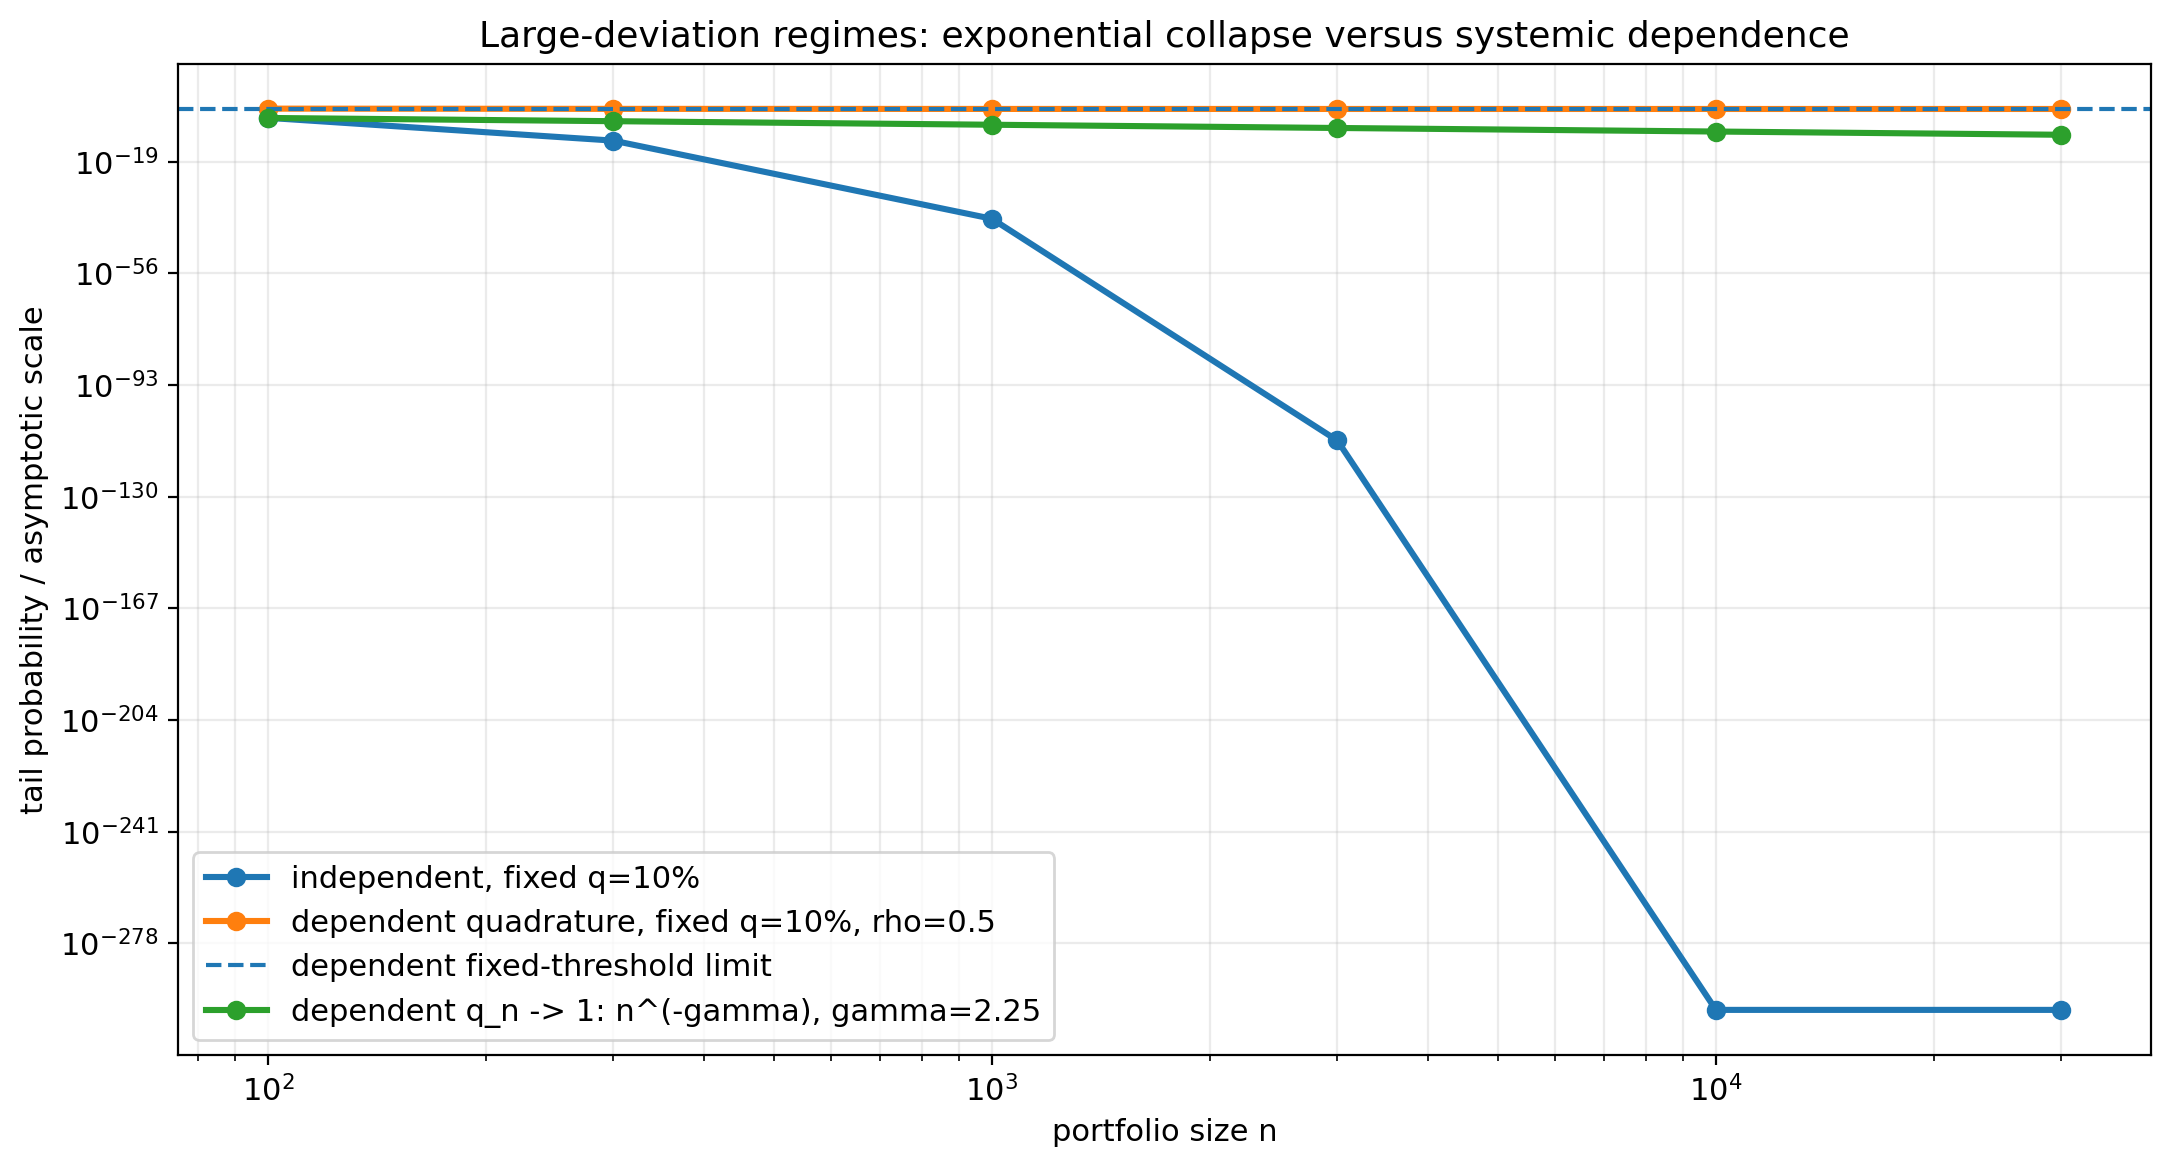

In [17]:
n_regime_grid = np.array([100, 300, 1_000, 3_000, 10_000, 30_000])
q_fixed_regime = 0.10
rho_regime = 0.5
a_regime = 0.75

independent_fixed_tail = []
dependent_fixed_tail = []

for n_regime in n_regime_grid:
    threshold_count = int(np.ceil(n_regime * q_fixed_regime))
    independent_fixed_tail.append(
        max(float(binom.sf(threshold_count - 1, n_regime, p)), 1e-300)
    )

    dependent_result = credit_tail_probability_quadrature(
        n=int(n_regime),
        p=p,
        rho=rho_regime,
        q=q_fixed_regime,
        epsrel=1e-8,
    )
    dependent_fixed_tail.append(max(dependent_result.probability, 1e-300))

independent_fixed_tail = np.array(independent_fixed_tail)
dependent_fixed_tail = np.array(dependent_fixed_tail)

dependent_fixed_limit = limiting_dependent_tail_probability(
    q_fixed_regime,
    p=p,
    rho=rho_regime,
)

gamma_regime = gaussian_copula_large_loss_decay_rate(a=a_regime, rho=rho_regime)
dependent_extreme_asymptotic = n_regime_grid.astype(float) ** (-gamma_regime)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    n_regime_grid,
    independent_fixed_tail,
    marker="o",
    linewidth=2.2,
    label=f"independent, fixed q={q_fixed_regime:.0%}",
)

ax.plot(
    n_regime_grid,
    dependent_fixed_tail,
    marker="o",
    linewidth=2.2,
    label=f"dependent quadrature, fixed q={q_fixed_regime:.0%}, rho={rho_regime}",
)

ax.axhline(
    dependent_fixed_limit,
    linestyle="--",
    linewidth=1.5,
    label="dependent fixed-threshold limit",
)

ax.plot(
    n_regime_grid,
    dependent_extreme_asymptotic,
    marker="o",
    linewidth=2.2,
    label=f"dependent q_n -> 1: n^(-gamma), gamma={gamma_regime:.2f}",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("portfolio size n")
ax.set_ylabel("tail probability / asymptotic scale")
ax.set_title("Large-deviation regimes: exponential collapse versus systemic dependence")
ax.legend(loc="best")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()


In [18]:
fixed_q = 0.10
n_compare_values = [100, 500, 2_000, 10_000]
rho_dependent = 0.5

rows = []

for n_compare in n_compare_values:
    independent_threshold = int(np.ceil(n_compare * fixed_q))
    independent_tail = float(binom.sf(independent_threshold - 1, n_compare, p))

    dependent_result = credit_tail_probability_quadrature(
        n=n_compare,
        p=p,
        rho=rho_dependent,
        q=fixed_q,
        epsrel=1e-8,
    )

    rows.append(
        {
            "n": n_compare,
            "independent_tail_rho_0": independent_tail,
            f"dependent_tail_rho_{rho_dependent}": dependent_result.probability,
            "quadrature_abs_error": dependent_result.absolute_error,
        }
    )

fixed_threshold_comparison = pd.DataFrame(rows)
display(fixed_threshold_comparison.style.format(precision=8))


,n,independent_tail_rho_0,dependent_tail_rho_0.5,quadrature_abs_error
0,100,0.00003442,0.03862178,0.00000000
1,500,0.00000000,0.03123527,0.00000000
2,2000,0.00000000,0.02994902,0.00000000
3,10000,0.00000000,0.02961142,0.00000000


In [19]:
limiting_dependent_tail = limiting_dependent_tail_probability(
    fixed_q,
    p=p,
    rho=rho_dependent,
)

print(
    f"Exact P[p(Z) >= {fixed_q:.2%}] for rho={rho_dependent}: "
    f"{limiting_dependent_tail:.8f}"
)


Exact P[p(Z) >= 10.00%] for rho=0.5: 0.02952738


### Fixed-threshold risk map

For a fixed threshold $q>p$, the independent portfolio has an exponentially small tail.

With dependence, as $n\to\infty$:

$$
\mathbb P(L_n/n\geq q)
\longrightarrow
\mathbb P(p(Z)\geq q).
$$

The heatmap below shows this limiting probability across:

```text
x-axis: rho
y-axis: q
color: log10 P[p(Z) >= q]
```

This is the most visual way to see why systemic dependence kills diversification.


In [20]:
rho_heatmap = np.linspace(0.02, 0.95, 120)
q_heatmap = np.linspace(max(p + 0.002, 0.025), 0.50, 120)

probability_surface = np.array(
    [
        [
            limiting_dependent_tail_probability(q=float(q), p=p, rho=float(rho))
            for rho in rho_heatmap
        ]
        for q in q_heatmap
    ]
)

log_probability_surface = np.log10(np.clip(probability_surface, 1e-16, 1.0))

fig = go.Figure(
    data=go.Heatmap(
        x=rho_heatmap,
        y=q_heatmap,
        z=log_probability_surface,
        colorbar=dict(title="log10 probability"),
        hovertemplate=(
            "rho=%{x:.2f}<br>"
            "threshold q=%{y:.1%}<br>"
            "log10 prob=%{z:.2f}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Fixed-threshold systemic risk map: log10 P[p(Z) >= q]",
    xaxis_title="factor loading rho",
    yaxis_title="loss threshold q",
    yaxis_tickformat=".0%",
    height=650,
)

fig.show()
export_interactive_figure(fig, "04_fixed_threshold_systemic_risk_map.html")


### Static output — GitHub-friendly systemic risk map

This is the static version of the interactive heatmap.

It is one of the strongest portfolio visuals because it turns the model into a risk dashboard.


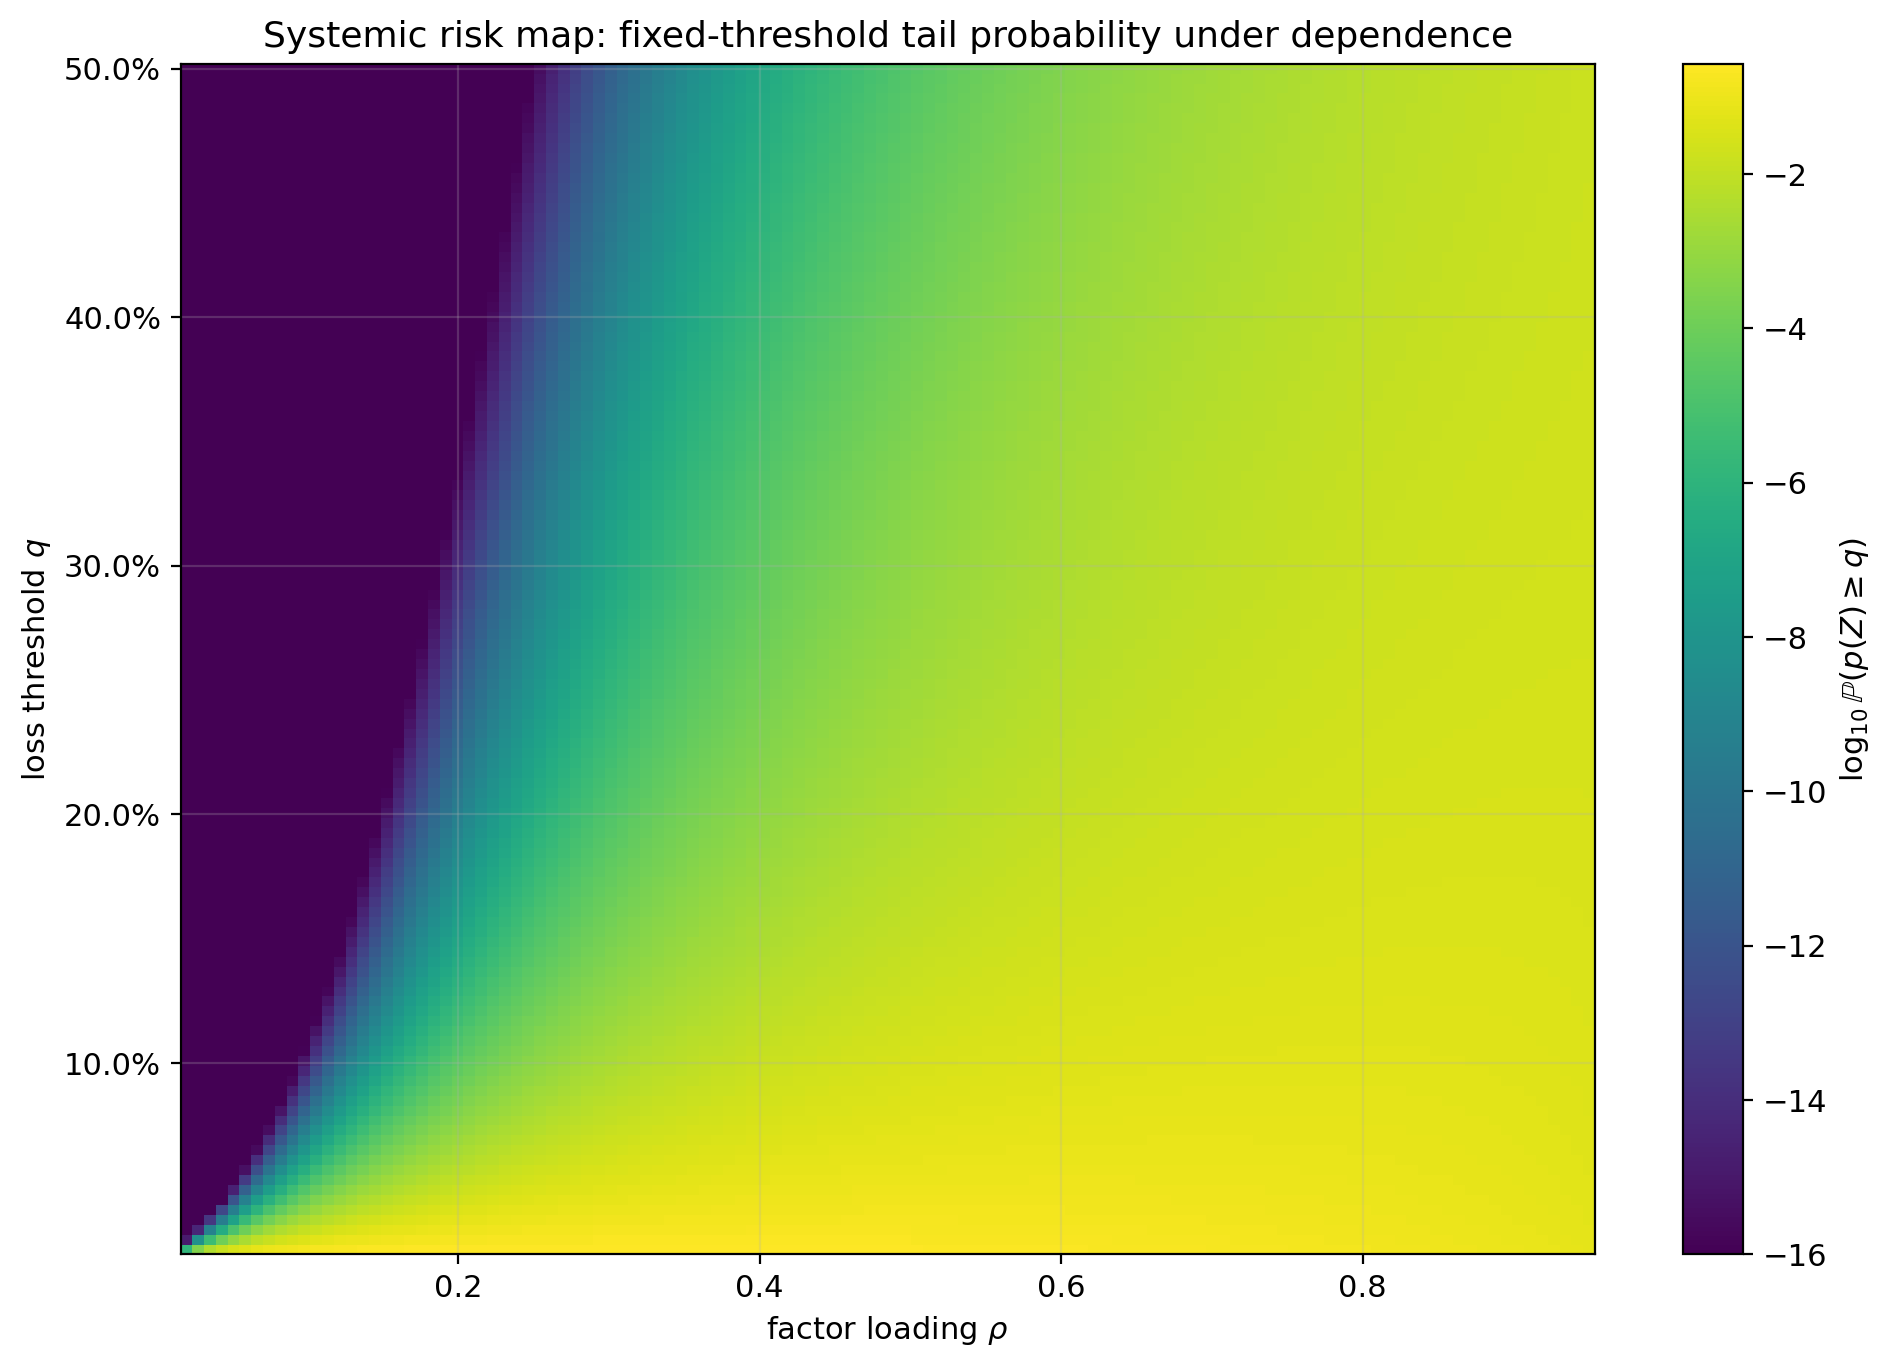

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))

mesh = ax.pcolormesh(
    rho_heatmap,
    q_heatmap,
    log_probability_surface,
    shading="auto",
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"$\log_{10}\mathbb{P}(p(Z)\geq q)$")

ax.set_xlabel(r"factor loading $\rho$")
ax.set_ylabel(r"loss threshold $q$")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Systemic risk map: fixed-threshold tail probability under dependence")

plt.tight_layout()
plt.show()


Read the heatmap from left to right.

```text
For small rho:
    a 10% loss threshold can be extremely rare.

For large rho:
    the same fixed threshold can have a visible probability,
    because one bad factor realization moves many obligors together.
```


The independent tail collapses.

The dependent fixed-threshold tail stabilizes near the probability that the systematic factor pushes $p(Z)$ above the threshold.

This is the key qualitative break.

## 11. Extreme thresholds $q_n \uparrow 1$

The final large-loss theorem studies:

$$
q_n\uparrow 1,
\qquad
1-q_n=O(n^{-a}),
\qquad
0<a\le 1.
$$

A simple version is:

$$
q_n = 1-n^{-a}.
$$

This asks for almost the entire portfolio to default.

In [22]:
a = 0.75
n_threshold_values = [100, 1_000, 10_000, 1_000_000]

threshold_rows = []

for n_threshold in n_threshold_values:
    q_n = large_loss_threshold_qn(n_threshold, a=a)
    threshold_rows.append(
        {
            "n": n_threshold,
            "a": a,
            "q_n": q_n,
            "1 - q_n": 1.0 - q_n,
            "required_defaults": math.ceil(n_threshold * q_n),
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.style.format(precision=8))

,n,a,q_n,1 - q_n,required_defaults
0,100,0.75000000,0.96837722,0.03162278,97
1,1000,0.75000000,0.99437659,0.00562341,995
2,10000,0.75000000,0.99900000,0.00100000,9990
3,1000000,0.75000000,0.99996838,0.00003162,999969


## 12. Large-loss decay exponent

In the homogeneous one-factor Gaussian copula model, Pham's large-loss asymptotic is:

$$
\lim_{n\to\infty}
\frac{1}{\log n}
\log \mathbb P(L_n\geq n q_n)
=
-a\frac{1-\rho^2}{\rho^2}.
$$

Equivalently,

$$
\mathbb P(L_n\geq n q_n)
\approx
n^{-\gamma},
\qquad
\gamma=a\frac{1-\rho^2}{\rho^2}.
$$

The exponent $\gamma$ decreases as dependence increases.

The important change in this version of the notebook is that we no longer only plot
the theoretical exponent. We compute the actual tail probability using quadrature.


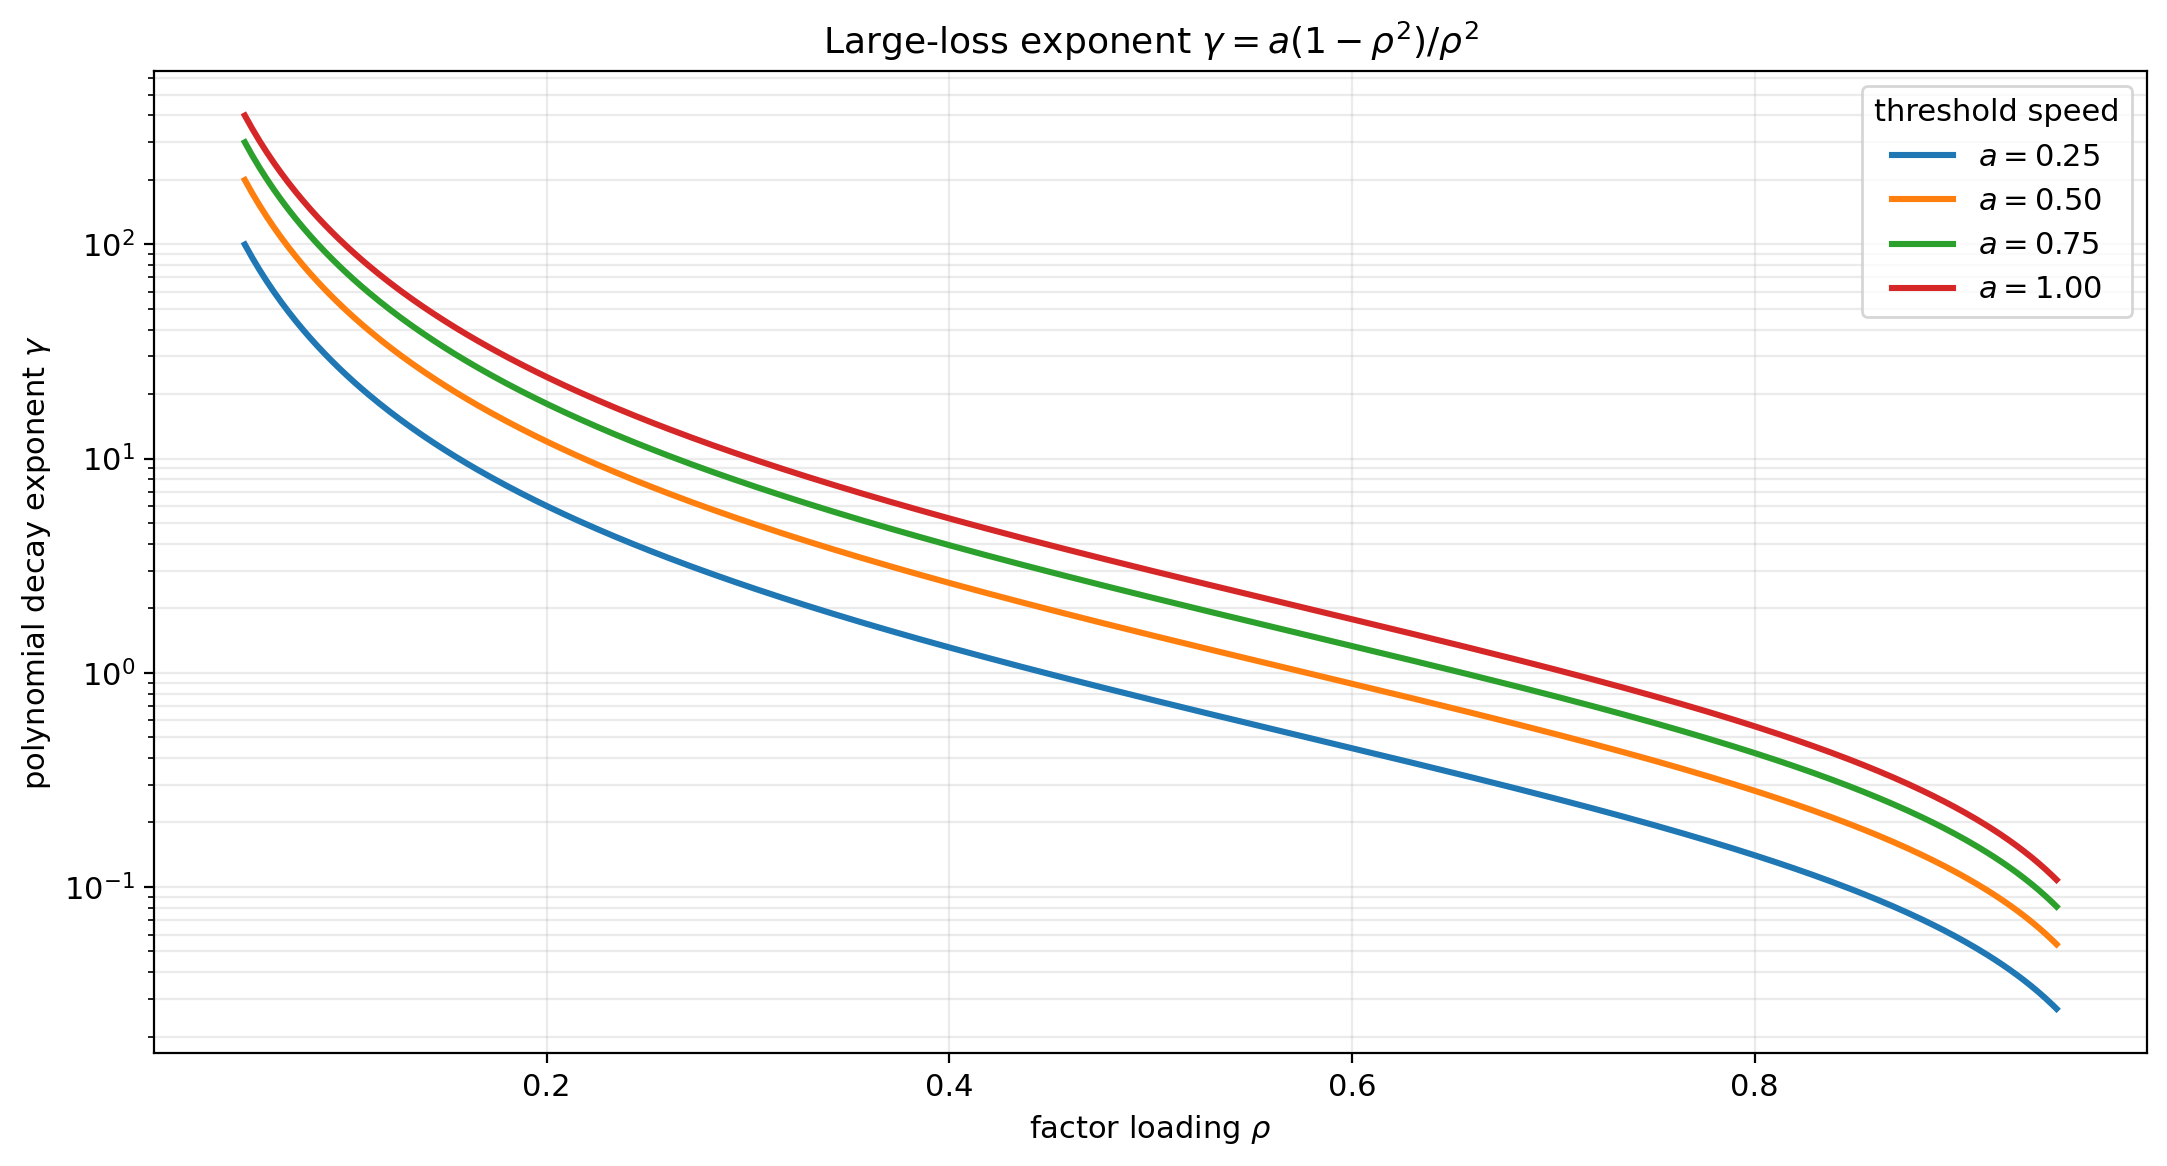

In [23]:
rho_grid_ld = np.linspace(0.05, 0.95, 500)
a_curve_values = [0.25, 0.50, 0.75, 1.00]

fig, ax = plt.subplots(figsize=(11, 6))

for a_curve in a_curve_values:
    gamma_curve = np.array(
        [
            gaussian_copula_large_loss_decay_rate(a=float(a_curve), rho=float(rho))
            for rho in rho_grid_ld
        ]
    )

    ax.plot(
        rho_grid_ld,
        gamma_curve,
        linewidth=2.2,
        label=fr"$a={a_curve:.2f}$",
    )

ax.set_yscale("log")
ax.set_xlabel(r"factor loading $\rho$")
ax.set_ylabel(r"polynomial decay exponent $\gamma$")
ax.set_title(r"Large-loss exponent $\gamma = a(1-\rho^2)/\rho^2$")
ax.legend(title="threshold speed")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()


## 13. Quadrature benchmark

Because

$$
L_n\mid Z=z\sim \mathrm{Binomial}(n,p(z)),
$$

the unconditional tail probability is

$$
\mathbb P(L_n\geq \lceil nq\rceil)
=
\int_{-\infty}^{+\infty}
\mathbb P\left(
\mathrm{Binomial}(n,p(z))\geq \lceil nq\rceil
\right)
\varphi(z)\,dz.
$$

This is the benchmark required before Monte Carlo or importance sampling.

The integration is split at $z_q$, defined by:

$$
p(z_q)=q.
$$

This split is not a modelling approximation. It is only a numerical convenience:

$$
\int_{-\infty}^{+\infty} f(z)\,dz
=
\int_{-\infty}^{z_q} f(z)\,dz
+
\int_{z_q}^{+\infty} f(z)\,dz.
$$


In [24]:
n_quad_demo = 1_000
q_quad_demo = 0.50
rho_quad_demo = 0.60

quad_demo = credit_tail_probability_quadrature(
    n=n_quad_demo,
    p=p,
    rho=rho_quad_demo,
    q=q_quad_demo,
    epsrel=1e-9,
)

quad_demo_table = pd.DataFrame(
    [
        {
            "n": n_quad_demo,
            "p": p,
            "rho": rho_quad_demo,
            "q": q_quad_demo,
            "threshold": quad_demo.threshold,
            "factor_split_z_q": quad_demo.factor_split,
            "probability": quad_demo.probability,
            "log_probability": quad_demo.log_probability,
            "quad_abs_error": quad_demo.absolute_error,
        }
    ]
)

display(
    quad_demo_table.style.format(
        {
            "p": "{:.2%}",
            "rho": "{:.2f}",
            "q": "{:.2%}",
            "factor_split_z_q": "{:.4f}",
            "probability": "{:.3e}",
            "log_probability": "{:.4f}",
            "quad_abs_error": "{:.3e}",
        }
    )
)


,n,p,rho,q,threshold,factor_split_z_q,probability,log_probability,quad_abs_error
0,1000,2.00%,0.60,50.00%,500,3.4229,3.172e-04,-8.0560,2.748e-14


### Where does the integral concentrate?

The function below plots the log-integrand:

$$
\log\left[
\mathbb P(\mathrm{Binomial}(n,p(z))\geq \lceil nq\rceil)
\varphi(z)
\right].
$$

The vertical line is $z_q$. To the right of this line, the conditional binomial tail
moves toward one, but the normal density $\varphi(z)$ becomes smaller. The integral
comes from the compromise between these two effects.


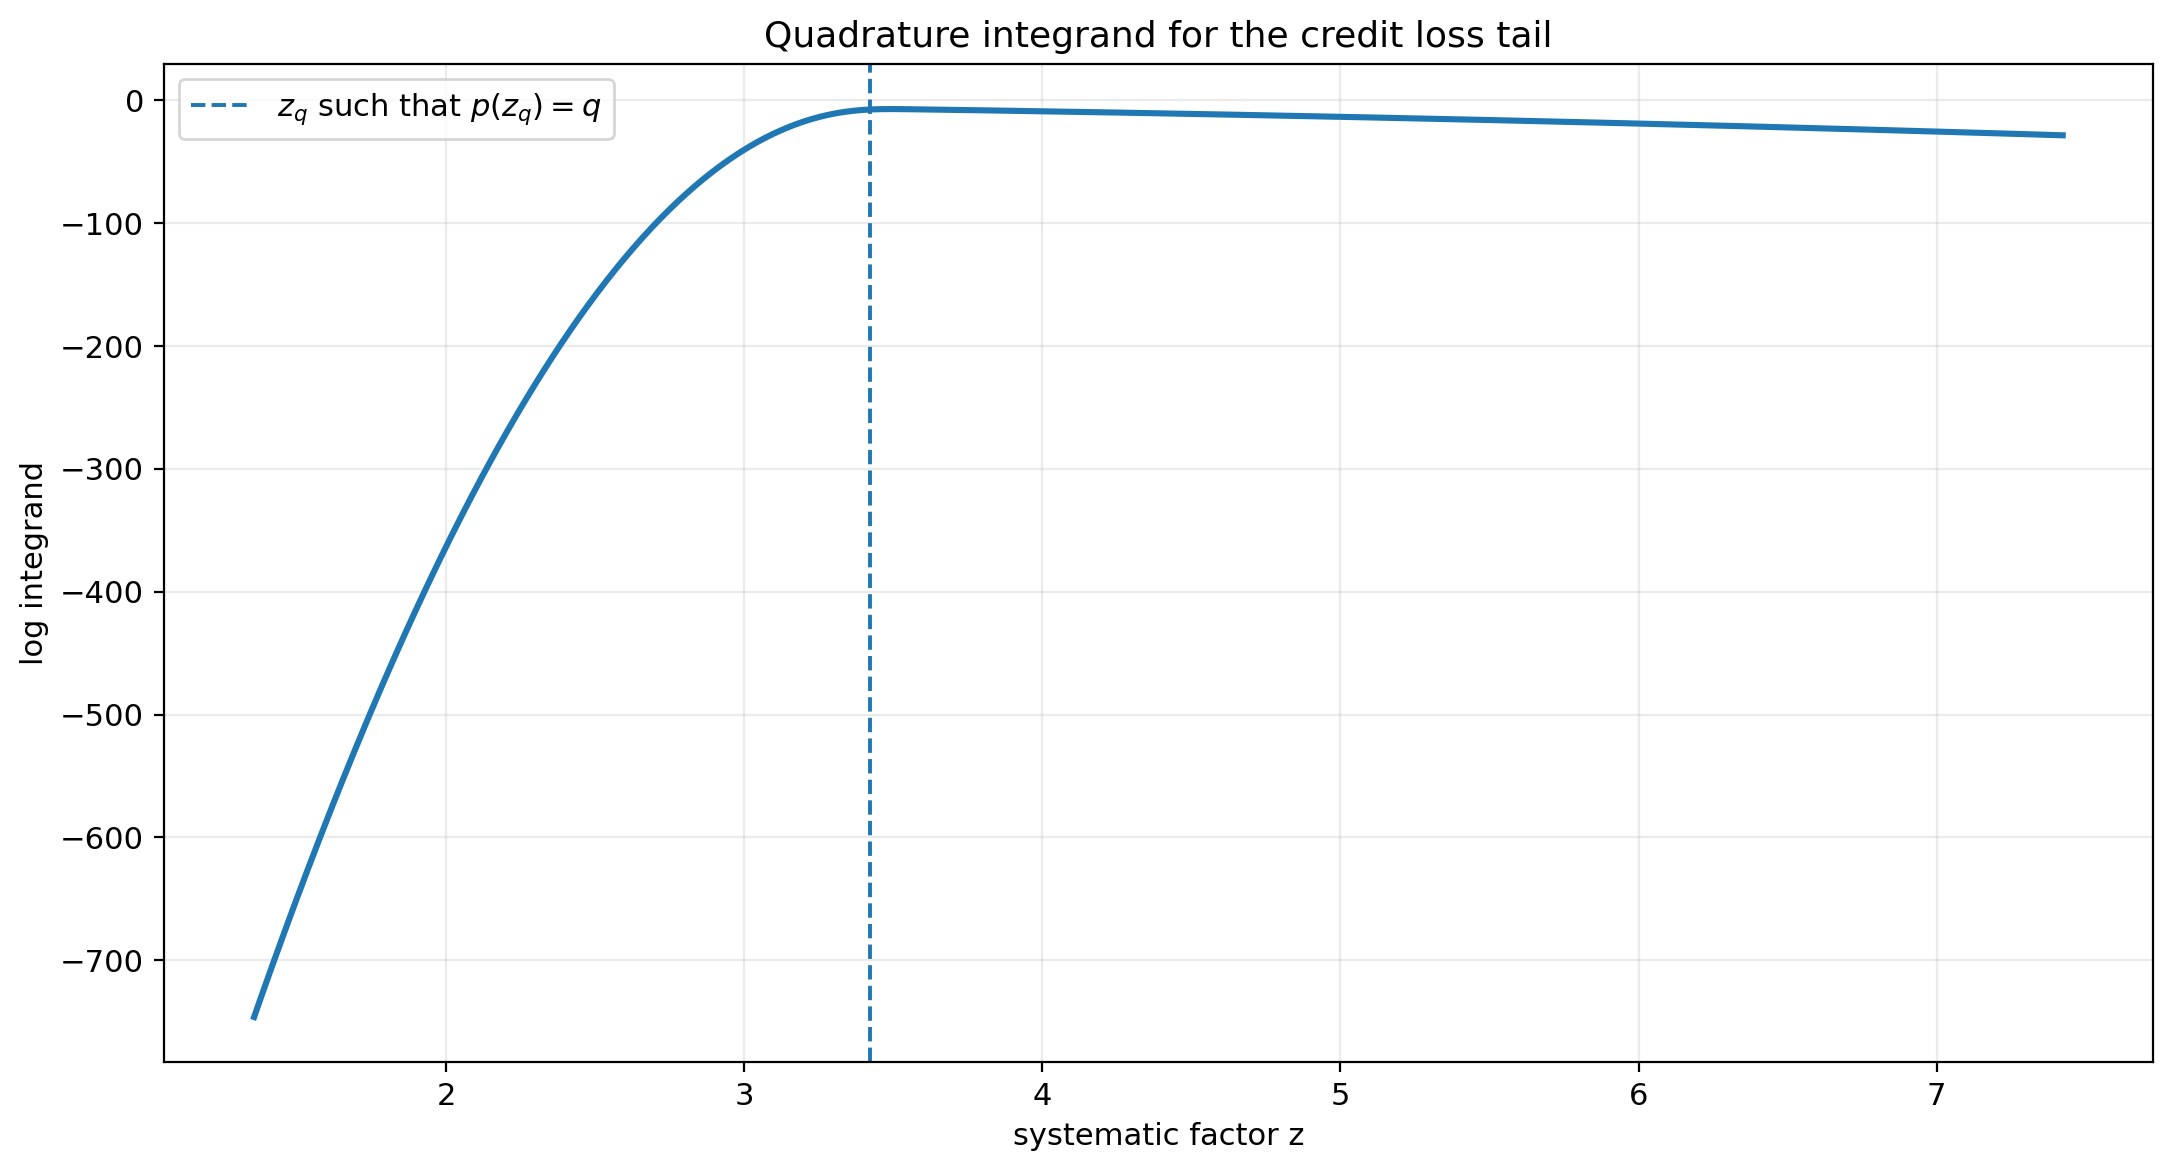

In [25]:
z_grid_integrand = np.linspace(
    max(-4.0, quad_demo.factor_split - 4.0),
    quad_demo.factor_split + 4.0,
    800,
)

log_integrand_values = np.array(
    [
        log_credit_tail_integrand(
            float(z),
            n=n_quad_demo,
            p=p,
            rho=rho_quad_demo,
            q=q_quad_demo,
        )
        for z in z_grid_integrand
    ]
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(z_grid_integrand, log_integrand_values, linewidth=2.2)
ax.axvline(
    quad_demo.factor_split,
    linestyle="--",
    linewidth=1.4,
    label=fr"$z_q$ such that $p(z_q)=q$",
)

ax.set_xlabel("systematic factor z")
ax.set_ylabel("log integrand")
ax.set_title("Quadrature integrand for the credit loss tail")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## 14. Numerical check of Theorem 6.1

For

$$
q_n = 1-c n^{-a},
$$

the theorem predicts:

$$
-\frac{\log \mathbb P(L_n\geq n q_n)}{\log n}
\longrightarrow
\gamma
=
a\frac{1-\rho^2}{\rho^2}.
$$

Finite-$n$ convergence can be slow, especially for credit-like small marginal default probabilities such as $p=2\%$. The table below therefore shows two diagnostics:

- $p = 50\%$: clean sanity check, faster convergence,
- $p = 2\%$: credit-like setting, slower convergence.

The theorem is asymptotic. The point is not to force exact agreement at small $n$, but to check that the computed log-log decay moves in the predicted direction.


In [26]:
a_theorem = 0.50
rho_theorem = 0.80
scale_theorem = 1.0
n_theorem_values = [100, 1_000, 10_000, 100_000, 1_000_000]
p_theorem_values = [0.50, p]

theorem_rows = []
theorem_results = {}

for p_theorem in p_theorem_values:
    result = compute_large_loss_asymptotic_curve(
        n_values=n_theorem_values,
        p=p_theorem,
        rho=rho_theorem,
        a=a_theorem,
        scale=scale_theorem,
        epsrel=1e-8,
    )
    theorem_results[p_theorem] = result

    for record in asymptotic_points_to_records(result.points):
        record["p"] = p_theorem
        record["rho"] = rho_theorem
        record["a"] = a_theorem
        record["theoretical_gamma"] = result.theoretical_decay_rate
        record["fitted_gamma_full_grid"] = result.fitted_decay_rate
        theorem_rows.append(record)

theorem_table = pd.DataFrame(theorem_rows)

display(
    theorem_table[
        [
            "p",
            "n",
            "q_n",
            "threshold",
            "probability",
            "log_probability",
            "empirical_decay_ratio",
            "theoretical_gamma",
            "fitted_gamma_full_grid",
        ]
    ].style.format(
        {
            "p": "{:.2%}",
            "q_n": "{:.6f}",
            "probability": "{:.3e}",
            "log_probability": "{:.4f}",
            "empirical_decay_ratio": "{:.4f}",
            "theoretical_gamma": "{:.4f}",
            "fitted_gamma_full_grid": "{:.4f}",
        }
    )
)


,p,n,q_n,threshold,probability,log_probability,empirical_decay_ratio,theoretical_gamma,fitted_gamma_full_grid
0,50.00%,100,0.900000,90,1.762e-01,-1.7359,0.3770,0.2812,0.3078
1,50.00%,1000,0.968377,969,8.207e-02,-2.5002,0.3619,0.2812,0.3078
2,50.00%,10000,0.990000,9900,4.071e-02,-3.2013,0.3476,0.2812,0.3078
3,50.00%,100000,0.996838,99684,2.031e-02,-3.8967,0.3385,0.2812,0.3078
4,50.00%,1000000,0.999000,999000,1.024e-02,-4.5816,0.3316,0.2812,0.3078
5,2.00%,100,0.900000,90,2.532e-04,-8.2812,1.7982,0.2812,0.6668
6,2.00%,1000,0.968377,969,3.840e-05,-10.1674,1.4719,0.2812,0.6668
7,2.00%,10000,0.990000,9900,8.211e-06,-11.7101,1.2714,0.2812,0.6668
8,2.00%,100000,0.996838,99684,1.972e-06,-13.1366,1.1410,0.2812,0.6668
9,2.00%,1000000,0.999000,999000,5.181e-07,-14.4730,1.0476,0.2812,0.6668


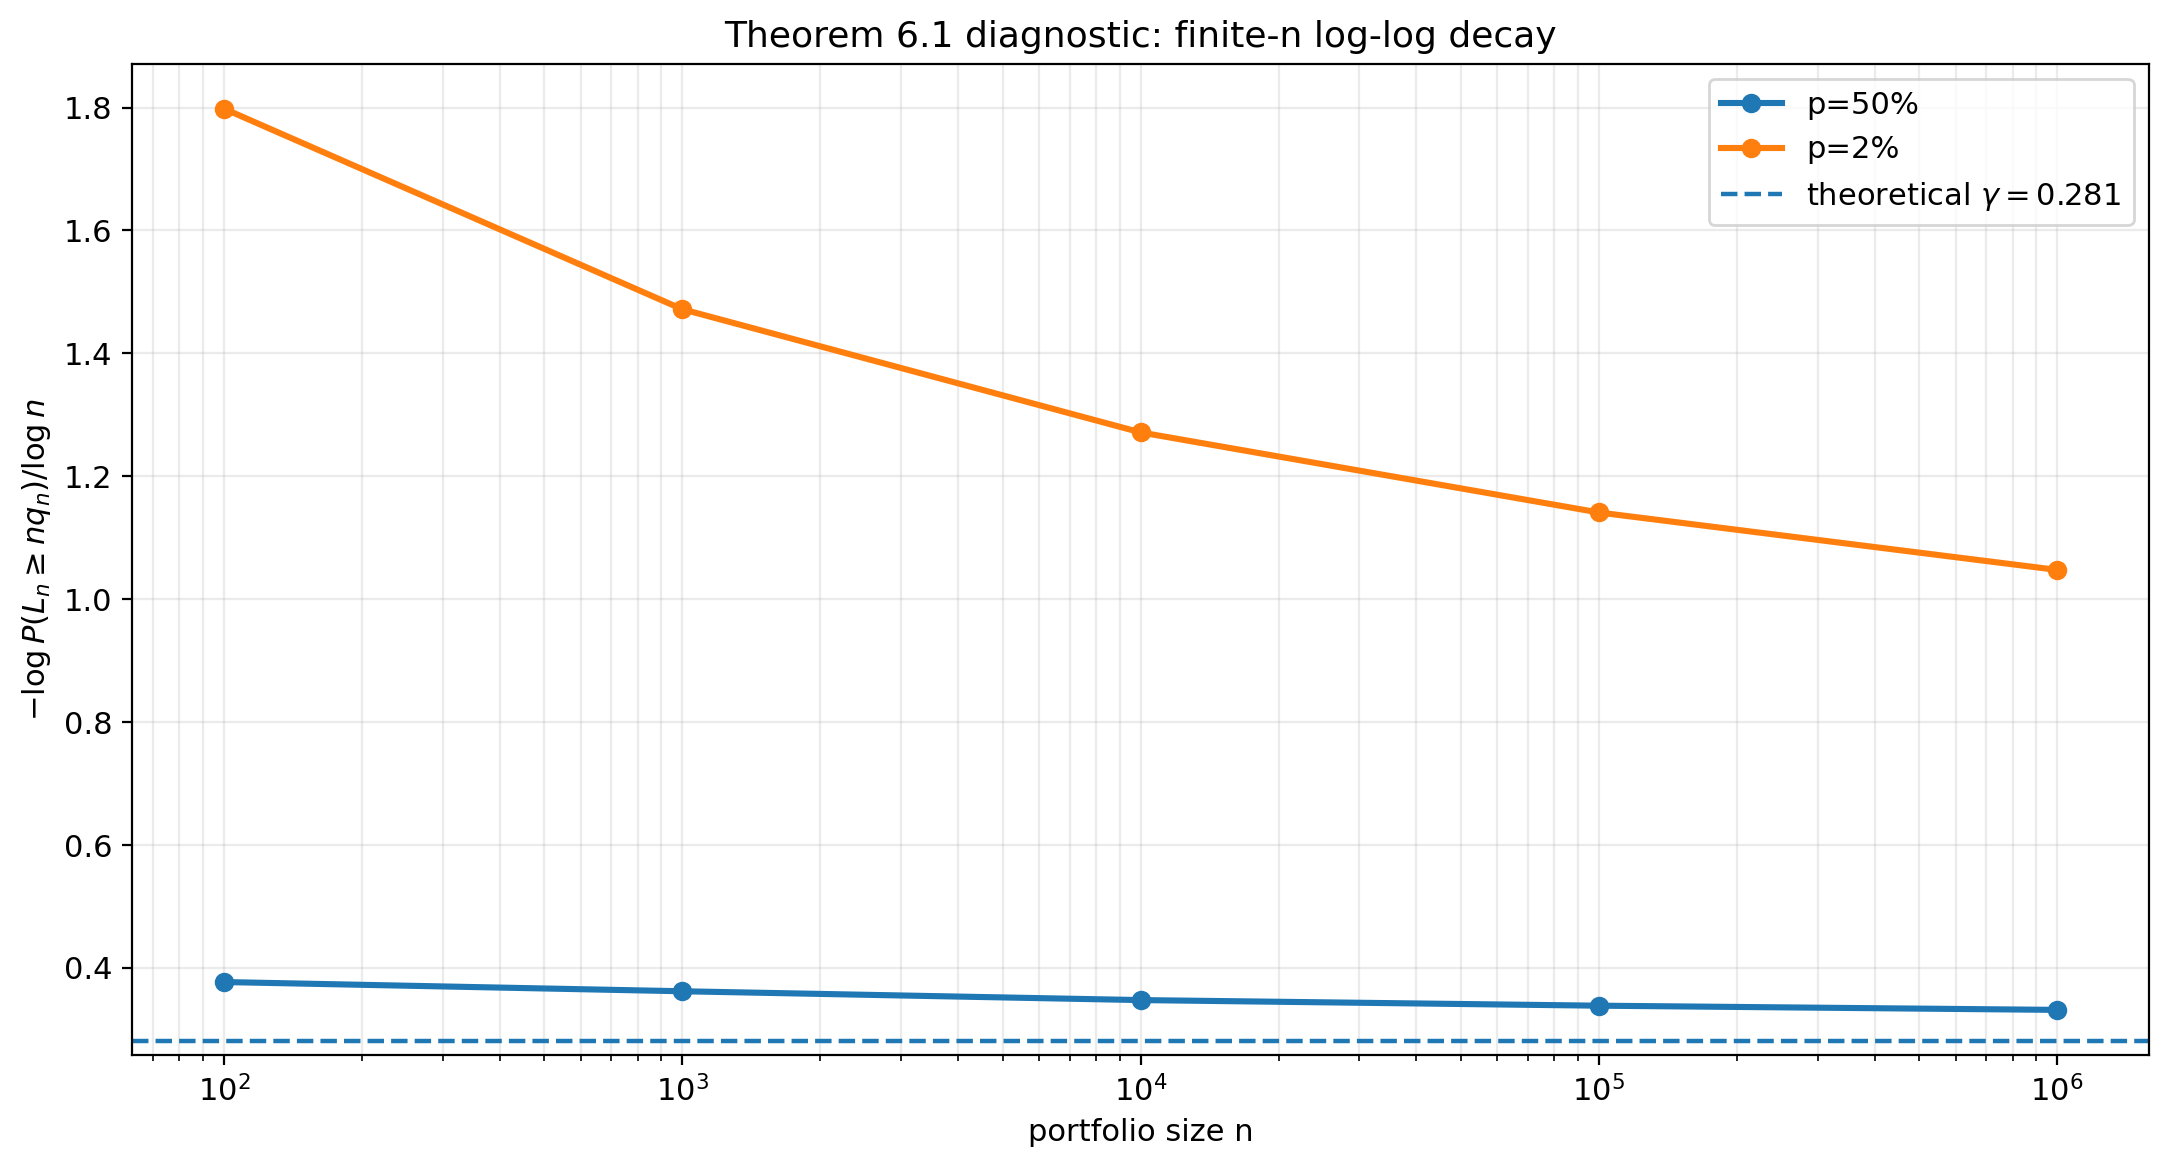

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))

for p_theorem, result in theorem_results.items():
    records = asymptotic_points_to_records(result.points)
    x = [row["n"] for row in records]
    y = [row["empirical_decay_ratio"] for row in records]

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2.2,
        label=f"p={p_theorem:.0%}",
    )

theoretical_gamma = next(iter(theorem_results.values())).theoretical_decay_rate

ax.axhline(
    theoretical_gamma,
    linestyle="--",
    linewidth=1.6,
    label=fr"theoretical $\gamma={theoretical_gamma:.3f}$",
)

ax.set_xscale("log")
ax.set_xlabel("portfolio size n")
ax.set_ylabel(r"$-\log P(L_n\geq n q_n) / \log n$")
ax.set_title("Theorem 6.1 diagnostic: finite-n log-log decay")
ax.legend()
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()


### Interpretation of the diagnostic

The clean case $p=50\%$ moves quickly toward the theoretical exponent because $\Phi^{-1}(p)=0$ removes a large finite-size correction.

The credit-like case $p=2\%$ converges much more slowly, and it is worth being precise about how slow this is. The theorem controls only the leading coefficient in front of $\log n$; the neglected terms (constants and $\log\log n$ contributions, driven by the fixed default threshold $\Phi^{-1}(p)$) therefore enter the ratio $-\log P_n/\log n$ at order $1/\log n$. Multiplying $n$ by 10 only adds $\log 10 \approx 2.3$ to the denominator, so the gap shrinks logarithmically: for instance with $p=2\%$, $\rho=0.5$, $a=0.5$ (theoretical $\gamma=1.5$), the fitted log-log slope is still about $2.9$ at $n=10^4$ and about $2.4$ at $n=10^8$.

This is why the notebook reports the theoretical $\gamma$, the empirical ratio $-\log(P_n)/\log(n)$, and the fitted $\gamma$ on the finite grid side by side, without overselling small-$n$ agreement — and why the unit tests in `tests/test_credit_dependent_case.py` assert the direction of convergence (the fitted slope stays above $\gamma$ and decreases toward it) rather than a meaningless closeness at test-sized $n$.


## 15. Bridge to two-step importance sampling

The quadrature benchmark gives us a reliable target:

$$
P_n = \mathbb P(L_n\geq n q_n).
$$

The next module should build a rare-event estimator for the same quantity.

The natural estimator is two-step:

```text
1. shift the systematic factor:
   Z ~ N(0,1) becomes Z ~ N(mu_n, 1)

2. conditionally on Z:
   tilt the Bernoulli defaults so that L_n >= n q_n becomes typical
```

That next step is not a replacement for quadrature. It is checked against quadrature.


## 16. Takeaways

The essential points:

```text
1. The Gaussian copula separates marginal default probability from dependence.
2. Given Z, the portfolio loss is binomial.
3. Therefore the credit tail can be benchmarked by one-dimensional quadrature.
4. Fixed thresholds do not remain rare under dependence.
5. The true dependent rare-event regime uses q_n -> 1.
6. Pham's Theorem 6.1 predicts polynomial decay n^{-gamma}.
7. Finite-n convergence is slow for small credit probabilities, so diagnostics must be honest.
```

The next implementation file is:

```text
src/large_deviations/credit/two_step_is.py
```

The next notebook section should compare the two-step importance sampling estimator
against the quadrature benchmark developed here.
